# $\nu_e$ CC Xsec Analysis

In [1]:
# CELL 0 — autoreload
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# CELL 1 — Imports
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import chi2 as scipy_chi2
from tqdm.auto import tqdm

# ── cafpyana root ─────────────────────────────────────────────────────────────
CAFPYANA_WD  = "/home/castalyf/cafpyana"   # ← adjust if needed
ANALYSIS_DIR = os.path.dirname(os.path.abspath("__file__"))

for p in [CAFPYANA_WD, CAFPYANA_WD + "/pyanalib", ANALYSIS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── this analysis's helpers ───────────────────────────────────────────────────
from nue_xsec_helpers import (
    VariableConfig,
    get_int_category,
    get_primary_reco_electron,
    get_primary_true_electron,
    build_nu_energy_reco,
    build_nu_energy_true,
    add_mcstat_weights,
    compute_mcstat_covariance,
    plot_stacked_topology,
    plot_heatmap,
    plot_uncertainty_budget,
    plot_unfolded_result,
    save_cov_npz,            
    make_equal_stats_bins, 
    CAT_LABELS, CAT_COLORS, CAT_PLOT_ORDER,
)

# ── existing nueCC reco helpers ───────────────────────────────────────────────
import nue_helpers   as nh
import nue_selection as ns

# ── cafpyana unfolding utilities ──────────────────────────────────────────────
from analysis_village.unfolding.utils import (
    WienerSVD,
    plot_overlay_with_cov,
    collect_inv_cov,
    get_smear_matrix,
    get_eff,
    get_response_matrix,
    bin_range_labels,
    get_text_color,
)

print("All imports OK")

All imports OK


In [3]:
# CELL 2 — Paths & Settings
DF_FILE  = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC.df"
PLOT_DIR = "./nuecc_xsec_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

SAVE_FIGS    = True
N_UNIVERSES  = 100
TITLE_PREFIX = r"SBND $\nu_e$CC Inclusive"

def savefig(fname):
    if SAVE_FIGS:
        plt.savefig(os.path.join(PLOT_DIR, fname), bbox_inches="tight", dpi=150)

print(f"Output dir : {PLOT_DIR}")
print(f"DF file    : {DF_FILE}")

Output dir : ./nuecc_xsec_plots
DF file    : /exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC.df


In [4]:
# CELL 3 — Load data
with pd.HDFStore(DF_FILE, mode="r") as store:
    keys     = store.keys()
    n_splits = int(store["split"]["n_split"].iloc[0])
    print(f"Keys   : {keys}")
    print(f"Splits : {n_splits}")

evt_frames, stats_frames, pot_frames, hdr_frames = [], [], [], []
for k in range(n_splits):
    evt_frames  .append(pd.read_hdf(DF_FILE, key=f"evt_{k}"))
    stats_frames.append(pd.read_hdf(DF_FILE, key=f"stats_{k}"))
    pot_frames  .append(pd.read_hdf(DF_FILE, key=f"pot_{k}"))
    hdr_frames  .append(pd.read_hdf(DF_FILE, key=f"hdr_{k}"))

evtdf   = pd.concat(evt_frames,   axis=0)
statsdf = pd.concat(stats_frames, axis=0)
potdf   = pd.concat(pot_frames,   axis=0)
hdrdf   = pd.concat(hdr_frames,   axis=0)

print(f"\nevtdf   : {evtdf.shape}")
print(f"statsdf : {statsdf.shape}")
print(f"Index   : {evtdf.index.names}")

Keys   : ['/evt_0', '/evt_1', '/hdr_0', '/hdr_1', '/histgenevtdf_0', '/histgenevtdf_1', '/histpotdf_0', '/histpotdf_1', '/pot_0', '/pot_1', '/split', '/stats_0', '/stats_1']
Splits : 2

evtdf   : (685791, 393)
statsdf : (30, 14)
Index   : ['__ntuple', 'entry', 'rec.dlp..index', 'rec.dlp.particles..index']


In [5]:
# CELL 4 — POT normalisation & physical constants

# ── Total MC POT from histpotdf ───────────────────────────────────────────────
hist_frames = []
for k in range(n_splits):
    try:
        hist_frames.append(pd.read_hdf(DF_FILE, key=f"histpotdf_{k}"))
    except KeyError:
        pass
histpotdf = pd.concat(hist_frames, axis=0) if hist_frames else pd.DataFrame()

pot_col    = "TotalPOT" if "TotalPOT" in histpotdf.columns \
             else histpotdf.select_dtypes("number").columns[0]
mc_tot_pot = float(histpotdf[pot_col].sum())

if mc_tot_pot == 0:
    raise RuntimeError("mc_tot_pot=0 — check histpotdf")

TARGET_POT = 6.6e20
pot_scale  = TARGET_POT / mc_tot_pot

print(f"MC total POT  : {mc_tot_pot:.3e}")
print(f"Target POT    : {TARGET_POT:.3e}")
print(f"POT scale     : {pot_scale:.4f}")

# ── Physical constants ─────────────────────────────────────────────────────────
RHO_AR    = 1.3836           # g/cm³
N_A       = 6.02214076e23
M_AR      = 39.948           # g/mol
V_ACTIVE  = 2 * 200 * 400 * 500   # cm³  ← update with official FV definition
N_TARGETS = RHO_AR * V_ACTIVE * N_A / M_AR
print(f"N_targets     : {N_TARGETS:.3e}")

# ── Integrated nue flux ───────────────────────────────────────────────────────
# TODO: load from ROOT flux file once path is confirmed:
#   import uproot
#   flux     = uproot.open("/exp/sbnd/data/users/.../sbnd_flux.root")
#   nue_flux = flux["flux_sbnd_nue"].to_numpy()           # (values, edges)
#   INTEGRATED_FLUX = nue_flux[0].sum() / 1e4             # /m² → /cm²
#   INTEGRATED_FLUX *= mc_tot_pot / 1e6                   # per 10^6 POT → per mc_tot_pot POT
#
INTEGRATED_FLUX  = 1.0    # PLACEHOLDER — update with real nue flux
XSEC_UNIT        = 1.0 / (INTEGRATED_FLUX * N_TARGETS * TARGET_POT)
XSEC_UNIT_EVENT  = 1.0   # dimensionless; use for event-rate closure tests

print(f"\nWARNING: INTEGRATED_FLUX is a placeholder — cross-section units not yet valid")
print(f"XSEC_UNIT        : {XSEC_UNIT:.3e}  (placeholder)")
print(f"XSEC_UNIT_EVENT  : {XSEC_UNIT_EVENT}  (event-rate mode, flux-independent)")

MC total POT  : 2.256e+19
Target POT    : 6.600e+20
POT scale     : 29.2553
N_targets     : 1.669e+30

XSEC_UNIT        : 9.080e-52  (placeholder)
XSEC_UNIT_EVENT  : 1.0  (event-rate mode, flux-independent)


In [6]:
# CELL 5 — Pre-cut truth counts from statsdf
print("=== Global pre-cut truth counts ===")
cols = ["n_inter_total","n_true_signal","n_after_fm","n_after_presel",
        "n_sig_after_fm","n_sig_after_presel"]
for c in cols:
    print(f"  {c:<25} = {statsdf[c].sum():>10,.0f}")

print("\nTruth category counts (pre-cut):")
for c in range(8):
    col = f"cat_{c}"
    if col in statsdf.columns:
        n   = statsdf[col].sum()
        tot = statsdf["n_inter_total"].sum()
        print(f"  cat {c}  {n:>9,.0f}  ({n/tot*100:5.1f}%)")

N_TRUE_SIGNAL_TOTAL = int(statsdf["n_true_signal"].sum())
print(f"\nEfficiency denominator: {N_TRUE_SIGNAL_TOTAL:,}")

=== Global pre-cut truth counts ===
  n_inter_total             =  2,810,430
  n_true_signal             =        670
  n_after_fm                =    251,656
  n_after_presel            =    144,287
  n_sig_after_fm            =        575
  n_sig_after_presel        =        570

Truth category counts (pre-cut):
  cat 0        670  (  0.0%)
  cat 1        407  (  0.0%)
  cat 2     15,297  (  0.5%)
  cat 3     12,435  (  0.4%)
  cat 4    171,604  (  6.1%)
  cat 5     53,962  (  1.9%)
  cat 6  2,493,974  ( 88.7%)
  cat 7     62,081  (  2.2%)

Efficiency denominator: 670


In [7]:
# CELL 6 — Truth categorisation & POT weight

il        = list(range(evtdf.index.nlevels - 1))   # interaction index levels
evtdf_int = evtdf.groupby(level=il).first()

print("Computing truth categories …")
nuint_categ = get_int_category(evtdf)    # returns interaction-level Series

evtdf_int = evtdf_int.copy()
evtdf_int["nuint_categ"] = nuint_categ
evtdf_int["pot_weight"]  = pot_scale

print("\nCategory breakdown (preselected df):")
vc = nuint_categ.value_counts().sort_index()
for cat, n in vc.items():
    print(f"  cat {cat}  {n:>8,}   {CAT_LABELS.get(cat, '?')}")

Computing truth categories …

Category breakdown (preselected df):
  cat 0       570   $\nu_e$ CC in FV (signal)
  cat 1        29   $\nu_e$ CC out of FV
  cat 2    10,927   $\nu_\mu$ CC $\pi^0$
  cat 3     6,989   NC $\pi^0$
  cat 4    88,224   Other $\nu_\mu$ CC
  cat 5    24,136   Other NC
  cat 6     6,120   Cosmic
  cat 7     7,292   Other


In [8]:
# CELL 7 — Variable configuration

var_cfg_eke = VariableConfig.electron_ke()        # T_e  [GeV]
var_cfg_cos = VariableConfig.electron_costheta()  # cos θ_e
var_cfg_enu = VariableConfig.nu_energy_reco()     # E_ν^reco  [GeV]

# ── Active variable ────────────────────────────────────────────────────────────
# Change to var_cfg_cos or var_cfg_enu to run those observables
var_cfg = var_cfg_eke

print(f"Active variable : {var_cfg.var_save_name}")
print(f"Bins            : {var_cfg.bins}")
print(f"n_bins          : {len(var_cfg.bins)-1}")
print(f"Axis label      : {var_cfg.var_labels[0]}")

Active variable : electron_ke
Bins            : [0.075 0.2   0.35  0.5   0.7   1.    1.5  ]
n_bins          : 6
Axis label      : $\mathrm{T_e~[GeV]}$


In [9]:
# CELL 8 — Primary electron extraction

eps = 1e-8

# ── Reco: highest-KE primary reco electron per interaction ────────────────────
print("Extracting primary reco electrons …")
reco_e_df = get_primary_reco_electron(evtdf)
reco_e_df = reco_e_df.copy()
reco_e_df["nuint_categ"] = nuint_categ.reindex(reco_e_df.index, fill_value=7)
reco_e_df["pot_weight"]  = pot_scale

print(f"  Interactions with primary reco e– : {len(reco_e_df):,}")
print(f"  of which signal (cat 0)           : {(reco_e_df['nuint_categ']==0).sum():,}")

# ── Truth: highest-KE primary true electron per interaction ───────────────────
print("Extracting primary true electrons …")
true_e_df = get_primary_true_electron(evtdf)
true_e_df = true_e_df.copy()
true_e_df["nuint_categ"] = nuint_categ.reindex(true_e_df.index, fill_value=7)

print(f"  Interactions with primary true e– : {len(true_e_df):,}")

Extracting primary reco electrons …
  Interactions with primary reco e– : 4,060
  of which signal (cat 0)           : 545
Extracting primary true electrons …
  Interactions with primary true e– : 1,322


In [31]:
# CELL 9 — Load pre-computed selection df (from selection notebook)
# sel_qual has one row per FM+FV interaction, with boolean sel_* columns
# and precomputed reco_ke, reco_costheta, true_ke, true_costheta.

SEL_QUAL_FILE = "./nuecc_dfs/selected_nuecc_qual_v2.df"   # ← adjust path

sel_qual = pd.read_hdf(SEL_QUAL_FILE)
print(f"sel_qual shape : {sel_qual.shape}")
print(f"Columns        : {sel_qual.columns.tolist()}")
print(f"\nBoolean sel columns:")

CUT_ORDER = [c for c in ["sel_" + n for n in ns.CUT_NAMES_MORE]
             if c in sel_qual.columns]
print("sel_qual stage counts (cut order):")
for c in CUT_ORDER:
    print(f"  {c:<35} : {int(sel_qual[c].sum()):>7,}")
print(f"\nSample rows:")
print(sel_qual.head(3))


sel_qual shape : (144287, 16)
Columns        : ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'sel_electron_primary_score', 'sel_electron_pid_score', 'sel_vertex_distance', 'pot_scale']

Boolean sel columns:
sel_qual stage counts (cut order):
  sel_precut                          : 144,287
  sel_valid_flashmatch                : 144,287
  sel_fiducial                        : 144,287
  sel_single_electron                 :   4,060
  sel_electron_primary_score          :   2,150
  sel_electron_pid_score              :     653
  sel_vertex_distance                 :     559

Sample rows:
                               truth_cat  is_sig  reco_ke  reco_costheta  \
__ntuple entry rec.dlp..index                                              
0        0     3                       2   False      NaN            NaN   
         2     0                       3   False 

In [38]:
# CELL 10 — Variable definitions  (no sel_df dependency)
BINS_P   = np.array([100., 300., 500., 700., 900., 1200., 1500.])  # MeV/c
BINS_COS = np.linspace(-1., 1., 9)
BINS_KE  = None   # placeholder — filled in Cell 11 once sel_df exists

# Category 7 ("other neutrino" catch-all) is excluded from all histograms
# and purity/efficiency calculations, consistent with the selection notebook.
EXCLUDE_CATS = {7}
STACK_ORDER  = [c for c in [0, 1, 2, 3, 4, 5, 6] if c not in EXCLUDE_CATS]

VAR_CONFIGS = [
    dict(reco_col="reco_ke",       true_col="true_ke",
         bins=BINS_KE,
         label     = r"Leading electron KE [MeV]",
         label_reco= r"Leading electron KE$_{\rm reco}$ [MeV]",
         label_true= r"Leading electron KE$_{\rm true}$ [MeV]",
         name="electron_ke"),
    dict(reco_col="reco_p",        true_col="true_p",
         bins=BINS_P,
         label     = r"Leading electron $p_e$ [MeV/c]",
         label_reco= r"Leading electron $p_e^{\rm reco}$ [MeV/c]",
         label_true= r"Leading electron $p_e^{\rm true}$ [MeV/c]",
         name="electron_p"),
    dict(reco_col="reco_costheta", true_col="true_costheta",
         bins=BINS_COS,
         label     = r"Leading electron $\cos\theta$",
         label_reco= r"Leading electron $\cos\theta_{\rm reco}$",
         label_true= r"Leading electron $\cos\theta_{\rm true}$",
         name="electron_costheta"),
]

def _in_range(vals, lo, hi):
    """Return finite values in [lo, hi). Drops NaN/inf and out-of-range."""
    vals = np.asarray(vals, dtype=float)
    return vals[np.isfinite(vals) & (vals >= lo) & (vals < hi)]

def _sel_cat_vals(col, cat, lo, hi, df):
    mask = (df["truth_cat"] == cat) & df[col].notna()
    return _in_range(df.loc[mask, col].values, lo, hi)

print(f"Cell 10 done — STACK_ORDER={STACK_ORDER}  (cat 7 excluded)")

Cell 10 done — STACK_ORDER=[0, 1, 2, 3, 4, 5, 6]  (cat 7 excluded)


In [40]:
# CELL 11 — Selection masks and per-variable CV histograms
FINAL_SEL_COL = "sel_vertex_distance"

sel_mask = sel_qual[FINAL_SEL_COL].fillna(False).astype(bool)
sel_df   = sel_qual[sel_mask].copy()

# Drop category-7 ("other neutrino" catch-all) — not shown in histograms,
# not counted in purity; consistent with selection notebook's _row_stats.
n_cat7   = (sel_df["truth_cat"] == 7).sum()
sel_df   = sel_df[~sel_df["truth_cat"].isin(EXCLUDE_CATS)].copy()

sig_mask_sel = sel_df["truth_cat"] == 0
bkg_mask_sel = ~sig_mask_sel
presel_sig_mask = sel_qual["truth_cat"] == 0
presel_sig_df   = sel_qual[presel_sig_mask]

pot_scale = float(sel_qual["pot_scale"].iloc[0])

print(f"Selected (raw)   : {sel_mask.sum():,}")
print(f"Cat-7 removed    : {n_cat7:,}")
print(f"Selected (final) : {len(sel_df):,}  "
      f"(sig={sig_mask_sel.sum():,}, bkg={bkg_mask_sel.sum():,})")
print(f"Purity           : {sig_mask_sel.sum()/len(sel_df)*100:.1f}%  "
      f"← matches selection notebook")
print(f"pot_scale        : {pot_scale:.4f}")

# ── Equal-stats KE bins ───────────────────────────────────────────────────────
_ref_ke = sel_df.loc[sig_mask_sel, "reco_ke"].dropna().values
BINS_KE = make_equal_stats_bins(_ref_ke, n_bins=6, lo=75., hi=1500.)
next(vc for vc in VAR_CONFIGS if vc["name"] == "electron_ke")["bins"] = BINS_KE

_counts_check, _ = np.histogram(
    _ref_ke[(_ref_ke >= 75.) & (_ref_ke < 1500.)], bins=BINS_KE
)
print(f"\nEqual-stats KE bins [MeV] : {np.round(BINS_KE, 1)}")
print(f"Bin widths          [MeV] : {np.round(np.diff(BINS_KE), 1)}")
print(f"Signal counts per bin     : {_counts_check}")

# ── Per-variable histograms ───────────────────────────────────────────────────
hists = {}
for vc in VAR_CONFIGS:
    rc, tc = vc["reco_col"], vc["true_col"]
    bins   = vc["bins"]
    lo, hi = bins[0], bins[-1]

    raw = sel_df[rc].values.astype(float)
    print(f"\n{vc['name']:20s}  "
          f"below_lo={( raw[np.isfinite(raw)] <  lo).sum():4d}  "
          f"above_hi={( raw[np.isfinite(raw)] >= hi).sum():4d}  "
          f"non-finite={(~np.isfinite(raw)).sum():4d}")

    sig_reco = _in_range(sel_df.loc[sig_mask_sel, rc].values, lo, hi)
    bkg_reco = _in_range(sel_df.loc[bkg_mask_sel, rc].values, lo, hi)
    sig_true = _in_range(sel_df.loc[sig_mask_sel, tc].values, lo, hi)
    pre_true = _in_range(presel_sig_df[tc].values,             lo, hi)

    def _hist(vals, bins=bins, w=pot_scale):
        return np.histogram(vals, bins=bins,
                            weights=np.full(len(vals), w))[0]

    nevts_sig_reco  = _hist(sig_reco)
    nevts_bkg_reco  = _hist(bkg_reco)
    nevts_true_sel  = _hist(sig_true, w=1.)
    nevts_sig_truth = _hist(pre_true, w=1.)

    hists[vc["name"]] = dict(
        nevts_sig_reco  = nevts_sig_reco,
        nevts_bkg_reco  = nevts_bkg_reco,
        nevts_total_reco= nevts_sig_reco + nevts_bkg_reco,
        nevts_true_sel  = nevts_true_sel,
        nevts_sig_truth = nevts_sig_truth,
    )
    print(f"  sig reco     : {nevts_sig_reco.sum():.1f}")
    print(f"  bkg reco     : {nevts_bkg_reco.sum():.1f}")
    print(f"  purity       : {nevts_sig_reco.sum()/max(nevts_sig_reco.sum()+nevts_bkg_reco.sum(),1)*100:.1f}%")
    print(f"  truth presel : {nevts_sig_truth.sum():.0f}")

Selected (raw)   : 559
Cat-7 removed    : 77
Selected (final) : 482  (sig=348, bkg=134)
Purity           : 72.2%  ← matches selection notebook
pot_scale        : 29.2553

Equal-stats KE bins [MeV] : [  75.   332.1  484.8  619.9  805.6 1140.5 1500. ]
Bin widths          [MeV] : [257.1 152.7 135.1 185.7 334.9 359.5]
Signal counts per bin     : [47 47 47 47 47 47]

electron_ke           below_lo=   0  above_hi= 120  non-finite=   0
  sig reco     : 8250.0
  bkg reco     : 2340.4
  purity       : 77.9%
  truth presel : 481

electron_p            below_lo=   0  above_hi= 121  non-finite=   0
  sig reco     : 8220.7
  bkg reco     : 2340.4
  purity       : 77.8%
  truth presel : 475

electron_costheta     below_lo=   0  above_hi=   0  non-finite=   0
  sig reco     : 10180.8
  bkg reco     : 3920.2
  purity       : 72.2%
  truth presel : 570


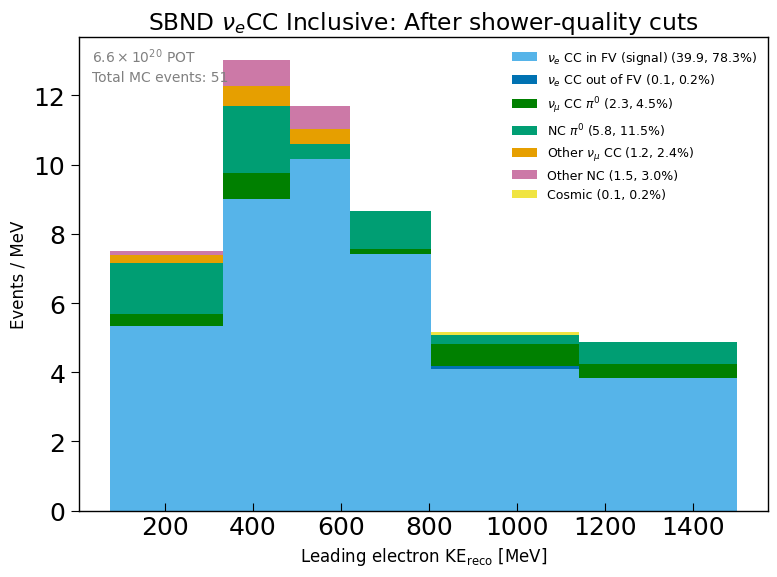

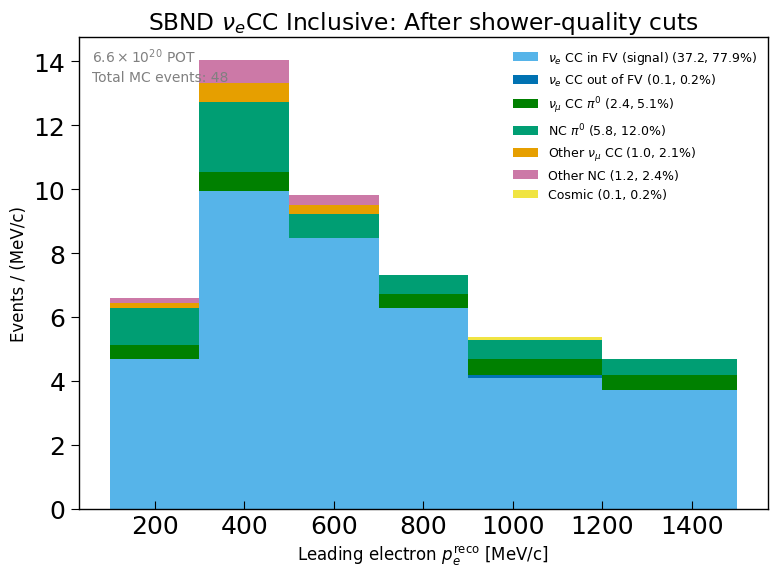

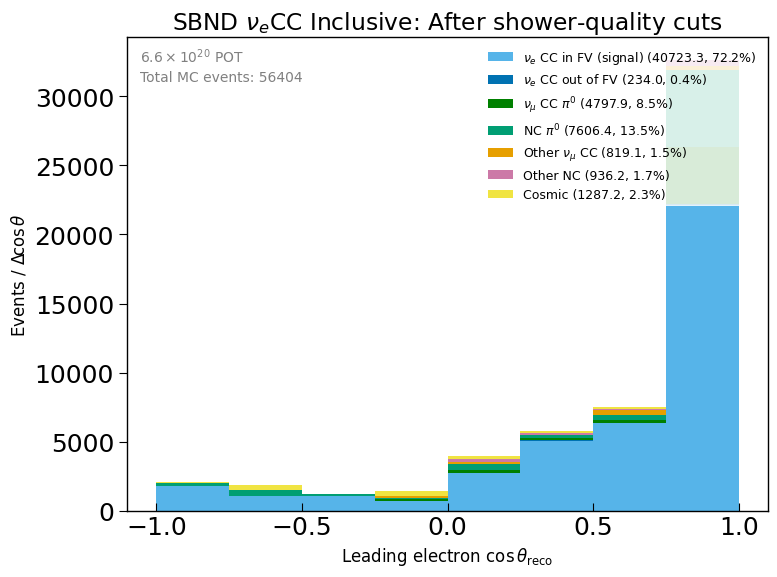

In [41]:
# CELL 12 — Stacked topology histograms  (events / unit → physical shape)

def _bin_width_weights(vals, bins, scalar_weight=1.0):
    """
    Return per-event weights = scalar_weight / bin_width.
    Converts raw counts to a density so equal-stats bins show the true spectrum shape.
    """
    vals   = np.asarray(vals, dtype=float)
    widths = np.diff(bins)
    idx    = np.clip(np.digitize(vals, bins) - 1, 0, len(widths) - 1)
    return scalar_weight / widths[idx]

_YLABELS = {
    "electron_ke":       "Events / MeV",
    "electron_p":        "Events / (MeV/c)",
    "electron_costheta": r"Events / $\Delta\!\cos\theta$",
}

for vc in VAR_CONFIGS:
    rc, bins = vc["reco_col"], vc["bins"]
    lo, hi   = bins[0], bins[-1]

    series_list  = [_sel_cat_vals(rc, c, lo, hi, sel_df) for c in STACK_ORDER]
    # Per-event weights include both POT normalisation and bin-width division
    weights_list = [_bin_width_weights(s, bins, pot_scale) for s in series_list]

    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list        = series_list,
        labels             = [CAT_LABELS[c] for c in STACK_ORDER],
        colors             = [CAT_COLORS[c] for c in STACK_ORDER],
        bins               = bins,
        weights            = weights_list,          # list of per-event arrays
        xlabel             = vc["label_reco"],
        ylabel             = _YLABELS.get(vc["name"], "Events / bin"),
        title              = fr"{TITLE_PREFIX}: After shower-quality cuts",
        pot_label          = fr"$6.6\times10^{{20}}$ POT",
        ax                 = ax,
        invert_stack_order = False,
    )
    plt.tight_layout()
    savefig(f"{vc['name']}_stack_sel.png")
    plt.show()

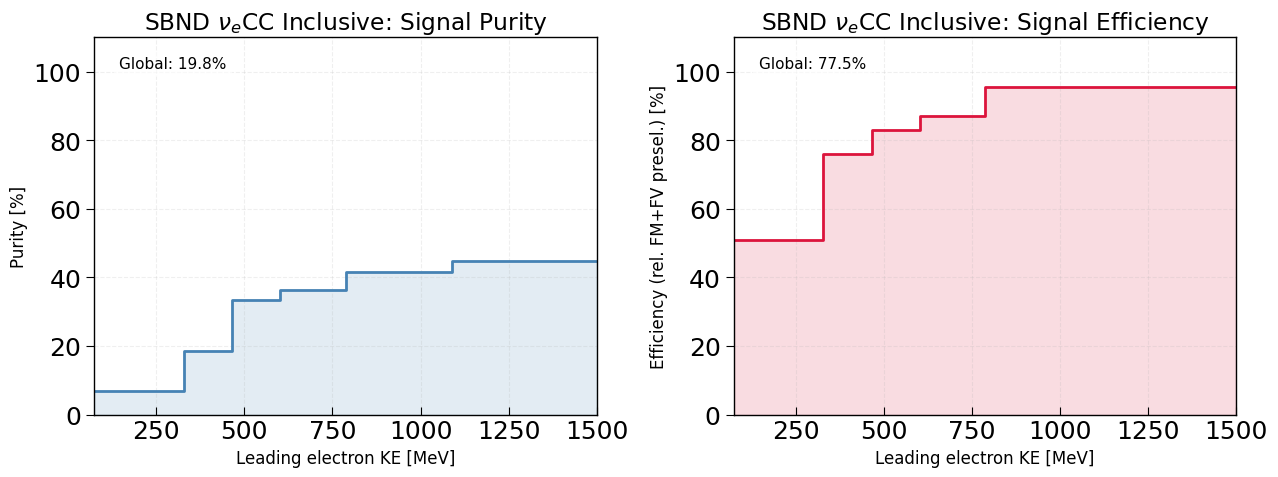

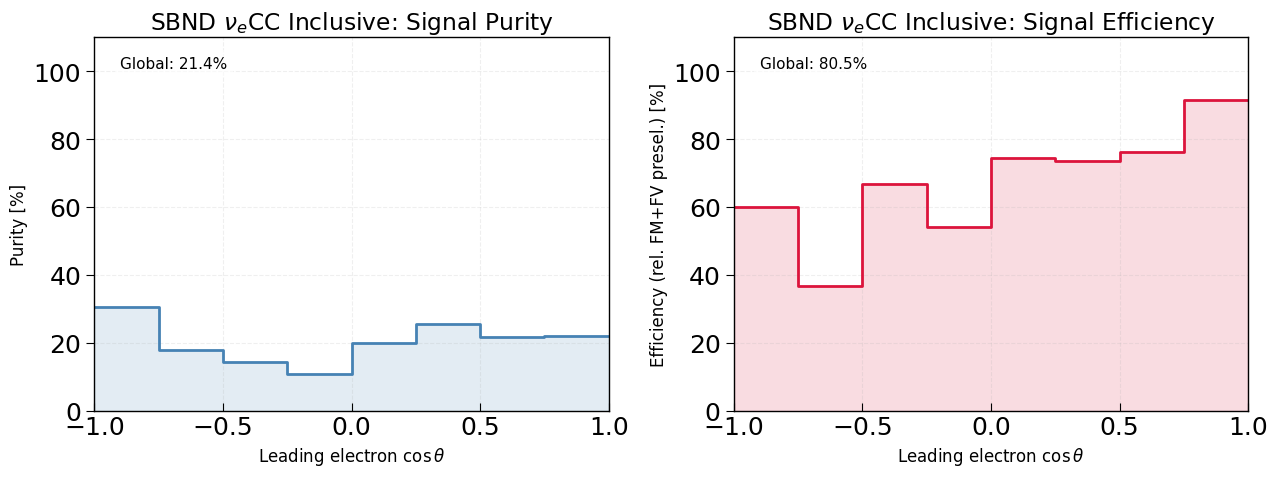

In [14]:
# CELL 13 — Purity and efficiency per bin (all variables)

for vc in VAR_CONFIGS:
    bins = vc["bins"]
    h    = hists[vc["name"]]
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    purity = np.divide(h["nevts_sig_reco"], h["nevts_total_reco"],
                       out=np.zeros_like(h["nevts_sig_reco"], dtype=float),
                       where=h["nevts_total_reco"] > 0)
    eff    = np.divide(h["nevts_true_sel"], h["nevts_sig_truth"],
                       out=np.zeros_like(h["nevts_true_sel"], dtype=float),
                       where=h["nevts_sig_truth"] > 0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, vals, ylabel, color, glbl in [
        (axes[0], purity*100, "Purity [%]",                         "steelblue",
         f"Global: {h['nevts_sig_reco'].sum()/max(h['nevts_total_reco'].sum(),1)*100:.1f}%"),
        (axes[1], eff*100,    "Efficiency (rel. FM+FV presel.) [%]", "crimson",
         f"Global: {h['nevts_true_sel'].sum()/max(h['nevts_sig_truth'].sum(),1)*100:.1f}%"),
    ]:
        ax.step(bins, np.append(vals, vals[-1]), where="post", color=color, lw=2)
        ax.fill_between(bins, np.append(vals, vals[-1]),
                        step="post", alpha=0.15, color=color)
        ax.set_xlim(bins[0], bins[-1]); ax.set_ylim(0, 110)
        ax.set_xlabel(vc["label"], fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(alpha=0.2, ls="--")
        ax.text(0.05, 0.95, glbl, transform=ax.transAxes,
                va="top", fontsize=11,
                bbox=dict(fc="white", alpha=0.6, ec="none"))

    axes[0].set_title(f"{TITLE_PREFIX}: Signal Purity")
    axes[1].set_title(f"{TITLE_PREFIX}: Signal Efficiency")
    plt.tight_layout()
    savefig(f"{vc['name']}_purity_efficiency.png")
    plt.show()

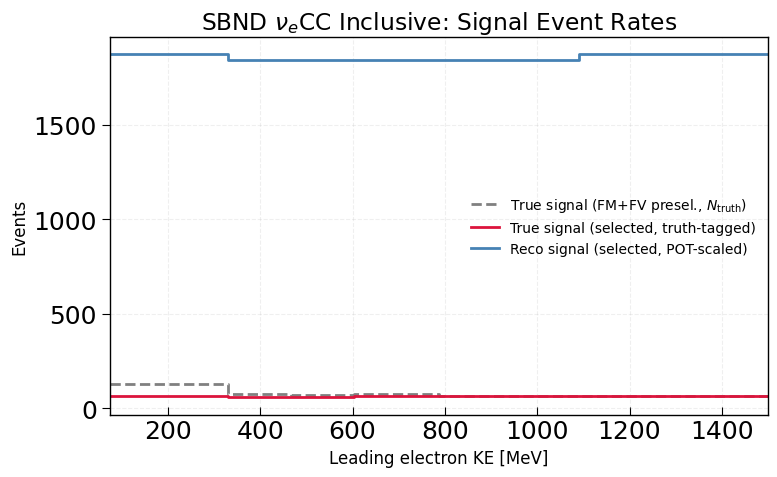

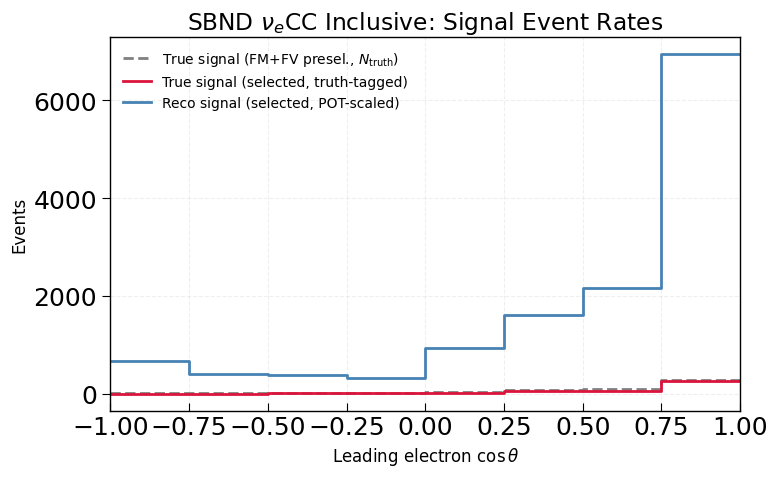

In [15]:
# CELL 14 — Signal event rates: reco vs. truth (all variables)

for vc in VAR_CONFIGS:
    bins = vc["bins"]
    h    = hists[vc["name"]]

    fig, ax = plt.subplots(figsize=(8, 5))
    for arr, color, ls, lbl in [
        (h["nevts_sig_truth"], "gray",      "--",
         r"True signal (FM+FV presel., $N_{\rm truth}$)"),
        (h["nevts_true_sel"],  "crimson",   "-",
         r"True signal (selected, truth-tagged)"),
        (h["nevts_sig_reco"],  "steelblue", "-",
         "Reco signal (selected, POT-scaled)"),
    ]:
        ax.step(bins, np.append(arr, arr[-1]),
                where="post", color=color, lw=2, ls=ls, label=lbl)

    ax.set_xlim(bins[0], bins[-1])
    ax.set_xlabel(vc["label"], fontsize=12)
    ax.set_ylabel("Events", fontsize=12)
    ax.set_title(f"{TITLE_PREFIX}: Signal Event Rates")
    ax.legend(frameon=False, fontsize=10)
    ax.grid(alpha=0.2, ls="--")
    plt.tight_layout()
    savefig(f"{vc['name']}_signal_rates.png")
    plt.show()

[[12. 11. 13.  9. 11.  8.]
 [ 7. 11.  9.  7. 14.  9.]
 [ 6. 11. 13.  9.  9. 10.]
 [12. 12.  6. 11. 14. 12.]
 [12. 10.  9. 11.  8. 14.]
 [14.  7. 12. 13.  6. 10.]]


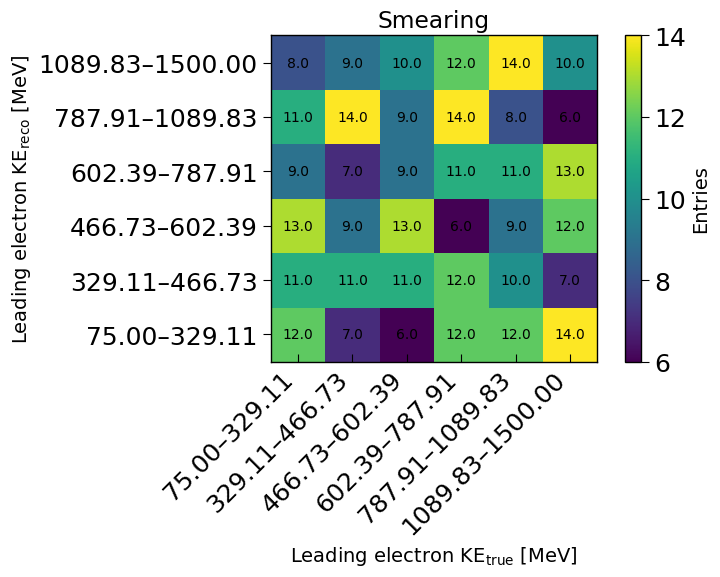

<Figure size 800x600 with 0 Axes>

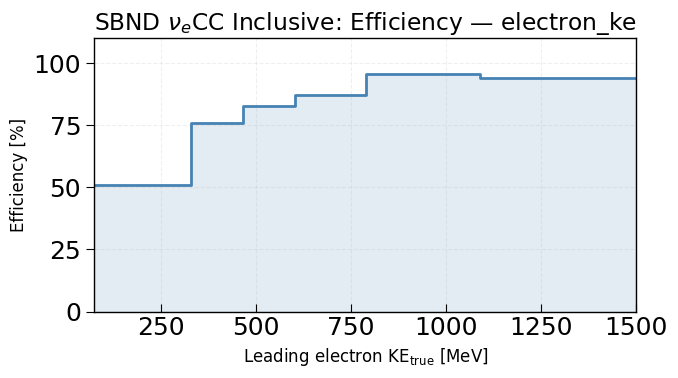

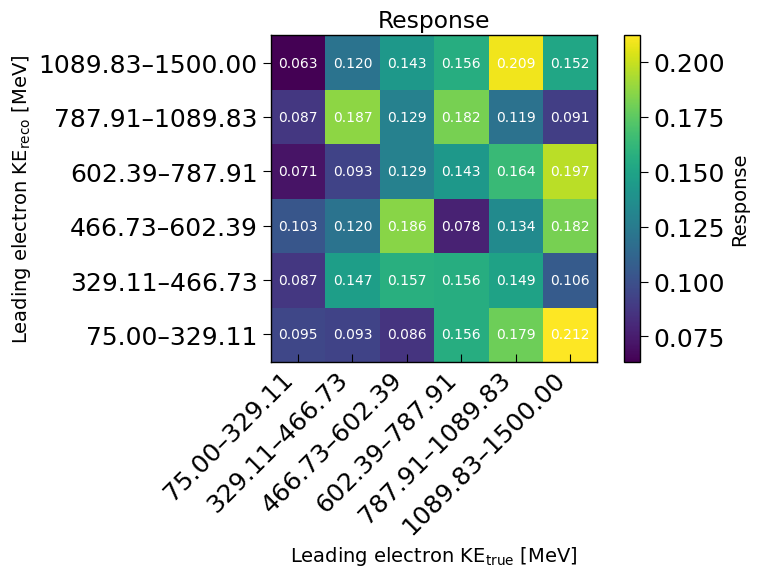

<Figure size 800x600 with 0 Axes>

electron_ke — column sums: [0.508 0.76  0.829 0.87  0.955 0.939]
[[  9.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   6.   0.   0.   1.   0.   0.   0.]
 [  0.   4.   9.   1.   0.   0.   0.   0.]
 [  1.   0.   3.   6.   2.   1.   0.   0.]
 [  0.   0.   0.   1.  24.   4.   0.   0.]
 [  0.   0.   0.   0.   4.  47.   2.   0.]
 [  1.   1.   1.   0.   0.   3.  60.   4.]
 [ 12.   3.   0.   3.   1.   0.  12. 233.]]


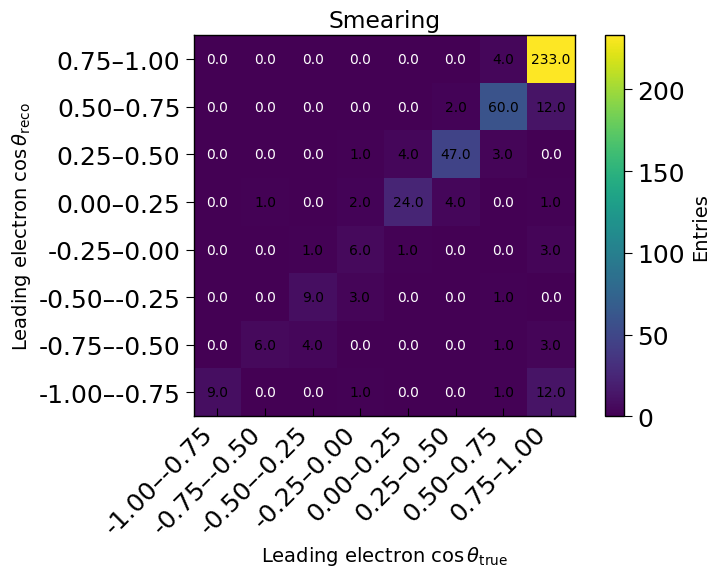

<Figure size 800x600 with 0 Axes>

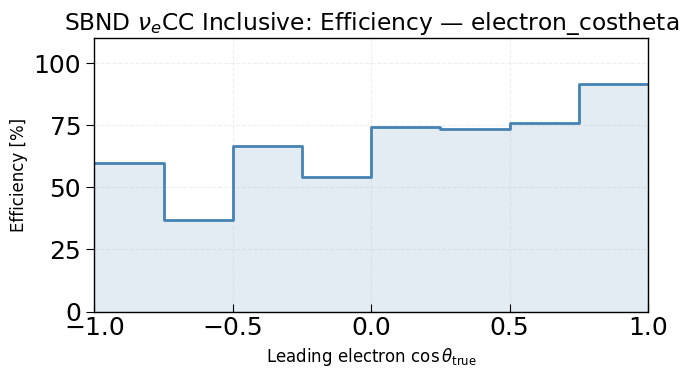

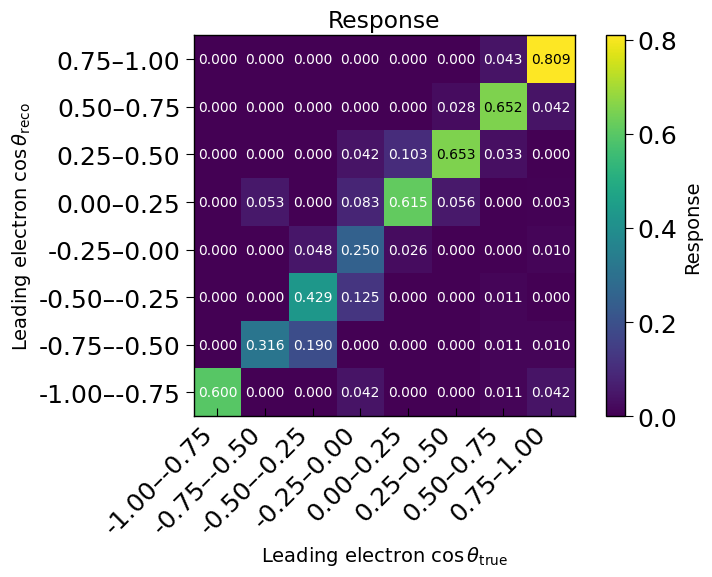

<Figure size 800x600 with 0 Axes>

electron_costheta — column sums: [0.6   0.368 0.667 0.542 0.744 0.736 0.761 0.917]


In [16]:
# CELL 15 — Response matrix (all variables)

Response_dict  = {}
eff_vec_dict   = {}
reco_vs_true_dict = {}

for vc in VAR_CONFIGS:
    rc, tc, bins = vc["reco_col"], vc["true_col"], vc["bins"]
    lo, hi = bins[0], bins[-1]
    h = hists[vc["name"]]

    # Selected signal reco + truth values (strict range, no overflow)
    sig_df = sel_df[sig_mask_sel]
    reco_vals = _in_range(sig_df[rc].values, lo, hi)
    # truth vals aligned to same events that passed the reco range filter
    reco_mask_range = (sig_df[rc] >= lo) & (sig_df[rc] < hi) & sig_df[rc].notna()
    true_vals = _in_range(sig_df.loc[reco_mask_range, tc].values, lo, hi)

    # Align lengths (drop any remaining NaN in true after range filter)
    min_len = min(len(reco_vals), len(true_vals))
    reco_vals = reco_vals[:min_len]
    true_vals = true_vals[:min_len]
    weight_sel = np.full(min_len, pot_scale)

    fig_name = os.path.join(PLOT_DIR, f"{vc['name']}_smearing_matrix")
    reco_vs_true = get_smear_matrix(
        true_vals, reco_vals, bins,
        var_labels=[vc["label"], vc["label_reco"], vc["label_true"]],
        save_fig=SAVE_FIGS, save_fig_name=fig_name,
    )
    plt.tight_layout()
    savefig(f"{vc['name']}_smearing_matrix.png")
    plt.show()

    eff_vec = get_eff(reco_vs_true, h["nevts_sig_truth"])

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.step(bins, np.append(eff_vec*100, eff_vec[-1]*100),
            where="post", color="steelblue", lw=2)
    ax.fill_between(bins, np.append(eff_vec*100, eff_vec[-1]*100),
                    step="post", alpha=0.15, color="steelblue")
    ax.set_xlim(bins[0], bins[-1]); ax.set_ylim(0, 110)
    ax.set_xlabel(vc["label_true"], fontsize=12)
    ax.set_ylabel("Efficiency [%]", fontsize=12)
    ax.set_title(f"{TITLE_PREFIX}: Efficiency — {vc['name']}")
    ax.grid(alpha=0.2, ls="--")
    plt.tight_layout()
    savefig(f"{vc['name']}_efficiency.png")
    plt.show()

    fig_name = os.path.join(PLOT_DIR, f"{vc['name']}_response_matrix")
    Response = get_response_matrix(
        reco_vs_true, eff_vec, bins,
        var_labels=[vc["label"], vc["label_reco"], vc["label_true"]],
        save_fig=SAVE_FIGS, save_fig_name=fig_name,
    )
    plt.tight_layout()
    savefig(f"{vc['name']}_response_matrix.png")
    plt.show()

    Response_dict[vc["name"]]    = Response
    eff_vec_dict[vc["name"]]     = eff_vec
    reco_vs_true_dict[vc["name"]]= reco_vs_true
    print(f"{vc['name']} — column sums: {np.round(Response.sum(axis=0), 3)}")

In [17]:
# CELL 16 — MCstat Poisson universes (computed once, shared across all variables)

rng = np.random.default_rng(42)
N   = len(sel_df)

row_seeds  = np.arange(N, dtype=np.uint32)
univ_seeds = rng.integers(0, 2**31, size=N_UNIVERSES, dtype=np.uint32)

mcstat_weights = np.ones((N_UNIVERSES, N), dtype=np.float32)
for u in tqdm(range(N_UNIVERSES), desc="Drawing MCstat universes"):
    combined     = (row_seeds + univ_seeds[u]) % (2**32)
    rng_u        = np.random.default_rng(int(combined.sum()) % (2**32))
    mcstat_weights[u] = rng_u.poisson(1.0, size=N).astype(np.float32)

print(f"Mean universe weight (expect ≈ 1.0): {mcstat_weights.mean():.4f}")

mcstat_df = pd.DataFrame(
    mcstat_weights.T,
    index   = sel_df.index,
    columns = [f"univ_{u}" for u in range(N_UNIVERSES)],
)

Drawing MCstat universes:   0%|          | 0/100 [00:00<?, ?it/s]

Mean universe weight (expect ≈ 1.0): 1.0030


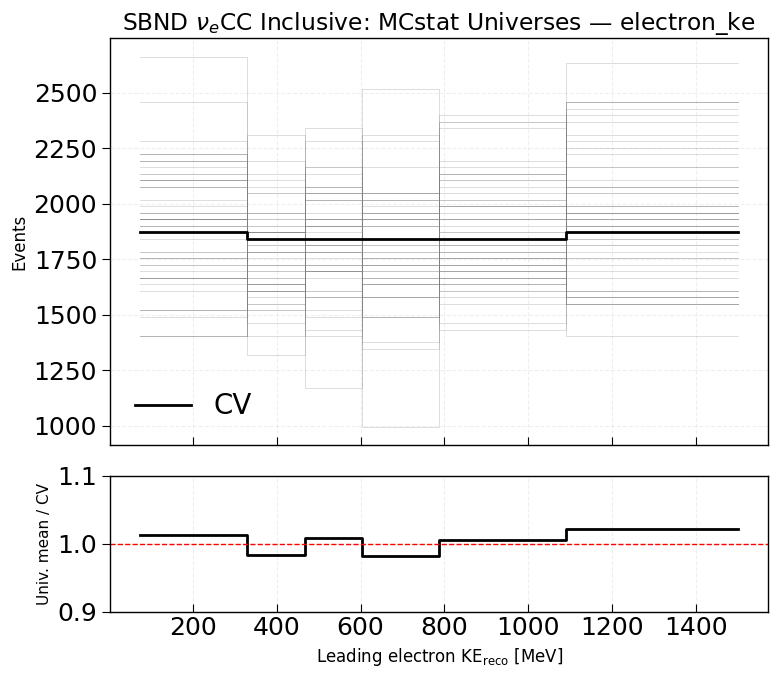

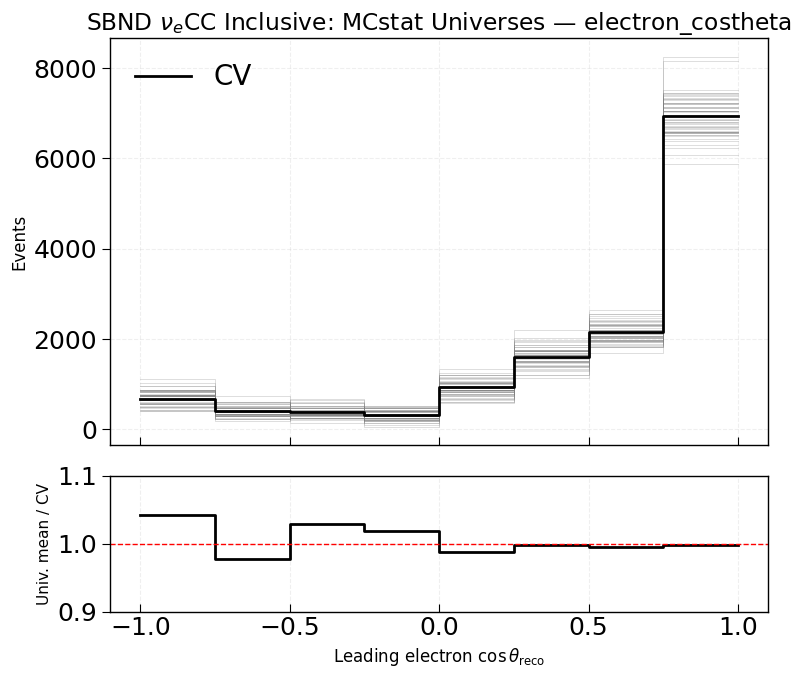

In [18]:
# CELL 17 — MCstat universe scatter plots (all variables)

for vc in VAR_CONFIGS:
    rc, bins = vc["reco_col"], vc["bins"]
    lo, hi   = bins[0], bins[-1]
    h        = hists[vc["name"]]
    cv_hist  = h["nevts_sig_reco"]

    # Strict range — no clipping
    sig_mask_range = (
        sig_mask_sel &
        sel_df[rc].notna() &
        (sel_df[rc] >= lo) &
        (sel_df[rc] < hi)
    )
    sig_vals = sel_df.loc[sig_mask_range, rc].values

    fig, axes = plt.subplots(2, 1, figsize=(8, 7),
                              gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

    for u in range(min(N_UNIVERSES, 60)):
        wgt_u = mcstat_df.loc[sig_mask_range, f"univ_{u}"].values * pot_scale
        uh, _ = np.histogram(sig_vals, bins=bins, weights=wgt_u)
        axes[0].step(bins, np.append(uh, uh[-1]), where="post",
                     color="gray", alpha=0.3, lw=0.6)

    axes[0].step(bins, np.append(cv_hist, cv_hist[-1]),
                 where="post", color="black", lw=2, label="CV")
    axes[0].set_ylabel("Events", fontsize=12)
    axes[0].set_title(f"{TITLE_PREFIX}: MCstat Universes — {vc['name']}")
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.2, ls="--")

    univ_stack = np.stack([
        np.histogram(sig_vals, bins=bins,
                     weights=mcstat_df.loc[sig_mask_range, f"univ_{u}"].values
                             * pot_scale)[0]
        for u in range(N_UNIVERSES)
    ])
    ratio_mean = np.divide(univ_stack.mean(axis=0), cv_hist,
                           out=np.ones(len(cv_hist), dtype=float),
                           where=cv_hist > 0)

    axes[1].step(bins, np.append(ratio_mean, ratio_mean[-1]),
                 where="post", color="black", lw=2)
    axes[1].axhline(1.0, color="red", ls="--", lw=1)
    axes[1].set_ylim(0.9, 1.1)
    axes[1].set_xlabel(vc["label_reco"], fontsize=12)
    axes[1].set_ylabel("Univ. mean / CV", fontsize=11)
    axes[1].grid(alpha=0.2, ls="--")

    plt.tight_layout()
    savefig(f"{vc['name']}_mcstat_universes.png")
    plt.show()

In [19]:
# CELL 18 — MCstat covariance matrices (all variables)

ret_mcstat_dict = {}

for vc in VAR_CONFIGS:
    rc, tc, bins = vc["reco_col"], vc["true_col"], vc["bins"]
    lo, hi   = bins[0], bins[-1]
    h        = hists[vc["name"]]
    n_bins   = len(bins) - 1

    # Strict range masks
    sig_range = sig_mask_sel & sel_df[rc].notna() & (sel_df[rc] >= lo) & (sel_df[rc] < hi)
    bkg_range = bkg_mask_sel & sel_df[rc].notna() & (sel_df[rc] >= lo) & (sel_df[rc] < hi)

    sig_vals = sel_df.loc[sig_range, rc].values
    bkg_vals = sel_df.loc[bkg_range, rc].values

    cv_sig = h["nevts_sig_reco"] * XSEC_UNIT_EVENT
    cv_bkg = h["nevts_bkg_reco"] * XSEC_UNIT_EVENT

    Cov, CovFrac = np.zeros((n_bins, n_bins)), np.zeros((n_bins, n_bins))

    for u in tqdm(range(N_UNIVERSES), desc=f"MCstat cov [{vc['name']}]", leave=False):
        wgt_sig_u = mcstat_df.loc[sig_range, f"univ_{u}"].values * pot_scale
        wgt_bkg_u = mcstat_df.loc[bkg_range, f"univ_{u}"].values * pot_scale

        sig_u, _ = np.histogram(sig_vals, bins=bins, weights=wgt_sig_u)
        bkg_u, _ = np.histogram(bkg_vals, bins=bins, weights=wgt_bkg_u)

        delta_bkg = (bkg_u - h["nevts_bkg_reco"]) * XSEC_UNIT_EVENT
        univ_val  = sig_u * XSEC_UNIT_EVENT + delta_bkg

        dv  = univ_val - cv_sig
        with np.errstate(divide="ignore", invalid="ignore"):
            dvf = np.where(cv_sig != 0, dv / cv_sig, 0.0)
        Cov     += np.outer(dv,  dv)
        CovFrac += np.outer(dvf, dvf)

    Cov     /= N_UNIVERSES
    CovFrac /= N_UNIVERSES
    diag_r   = np.sqrt(np.diag(Cov))
    with np.errstate(divide="ignore", invalid="ignore"):
        Corr = Cov / np.outer(np.where(diag_r > 0, diag_r, 1),
                               np.where(diag_r > 0, diag_r, 1))

    ret_mcstat_dict[vc["name"]] = dict(Covariance=Cov, Covariance_Frac=CovFrac,
                                       Correlation=Corr)
    print(f"\n{vc['name']} — fractional MCstat unc. per bin:")
    for lo_b, hi_b, f in zip(bins[:-1], bins[1:], np.sqrt(np.diag(CovFrac))):
        print(f"  [{lo_b:.1f}, {hi_b:.1f}]  {f*100:.1f}%")

MCstat cov [electron_ke]:   0%|          | 0/100 [00:00<?, ?it/s]


electron_ke — fractional MCstat unc. per bin:
  [75.0, 329.1]  44.0%
  [329.1, 466.7]  27.2%
  [466.7, 602.4]  21.2%
  [602.4, 787.9]  22.2%
  [787.9, 1089.8]  18.4%
  [1089.8, 1500.0]  17.3%


MCstat cov [electron_costheta]:   0%|          | 0/100 [00:00<?, ?it/s]


electron_costheta — fractional MCstat unc. per bin:
  [-1.0, -0.8]  38.3%
  [-0.8, -0.5]  59.0%
  [-0.5, -0.2]  78.8%
  [-0.2, 0.0]  101.4%
  [0.0, 0.2]  42.1%
  [0.2, 0.5]  25.2%
  [0.5, 0.8]  22.3%
  [0.8, 1.0]  11.6%


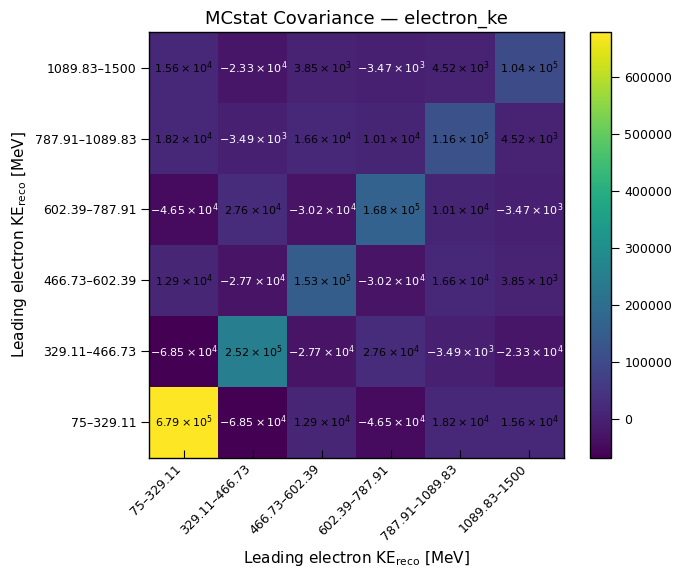

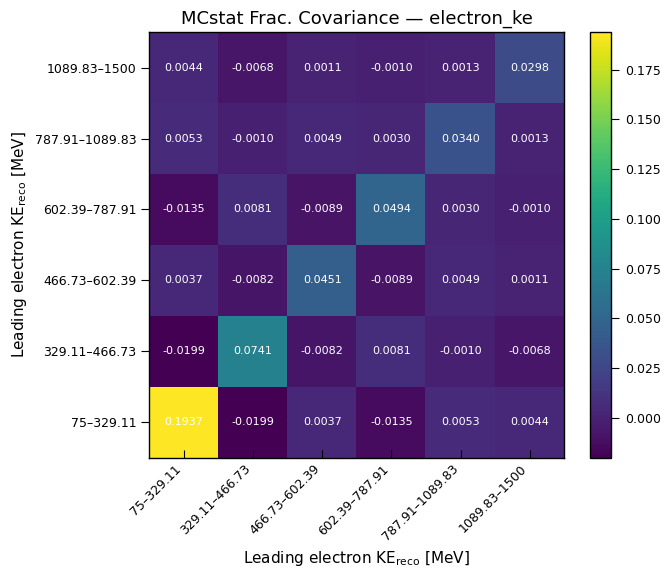

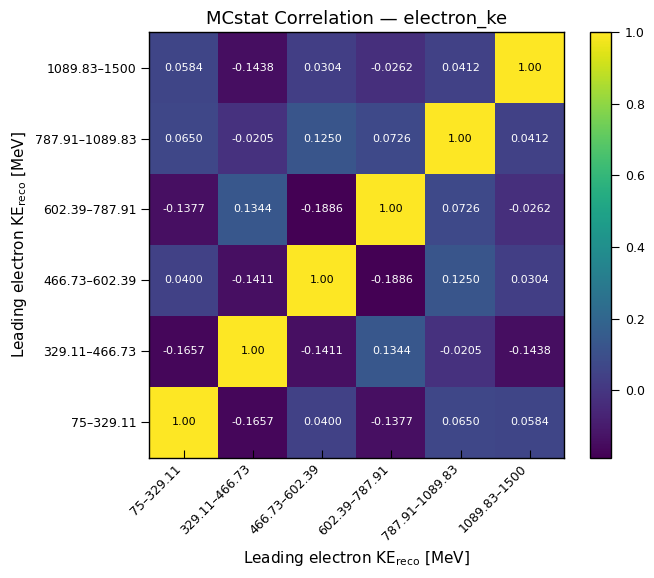

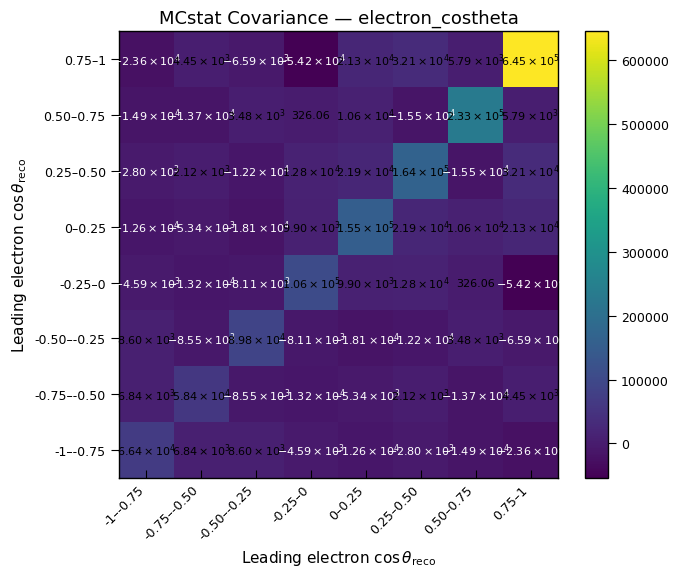

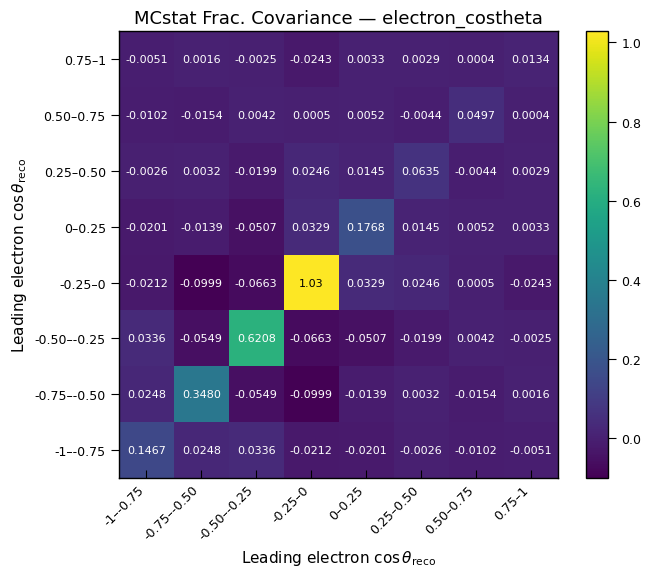

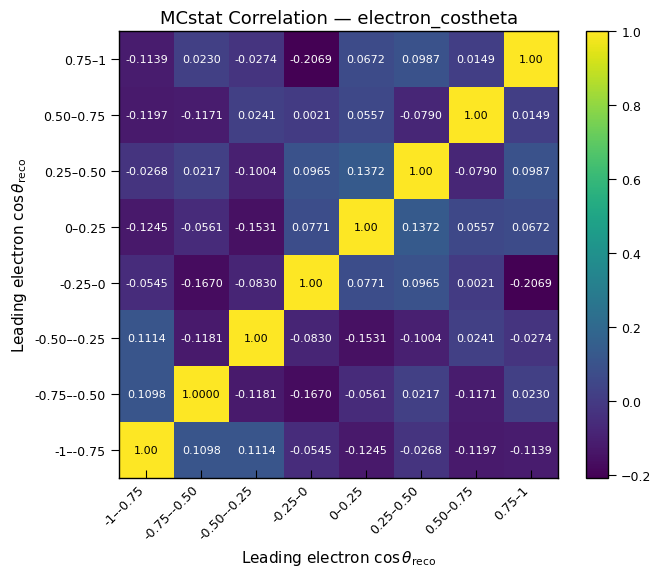

In [20]:
# CELL 19 — Covariance / correlation heatmaps (all variables)

from nue_xsec_helpers import plot_heatmap

for vc in VAR_CONFIGS:
    ret_mcstat = ret_mcstat_dict[vc["name"]]

    class _VCfg:
        bins          = vc["bins"]
        var_labels    = [vc["label"], vc["label_reco"], vc["label_true"]]
        var_plot_name = vc["label"]
    _vcfg = _VCfg()

    for key, label, fmt in [
        ("Covariance",      "MCstat Covariance",       ".2e"),
        ("Covariance_Frac", "MCstat Frac. Covariance", ".3f"),
        ("Correlation",     "MCstat Correlation",       ".2f"),
    ]:
        fig, ax = plot_heatmap(
            ret_mcstat[key], f"{label} — {vc['name']}", _vcfg,
            axis_labels=[vc["label_reco"], vc["label_reco"]],
            fmt=fmt,
        )
        savefig(f"{vc['name']}_mcstat_{key.lower()}.png")
        plt.show()

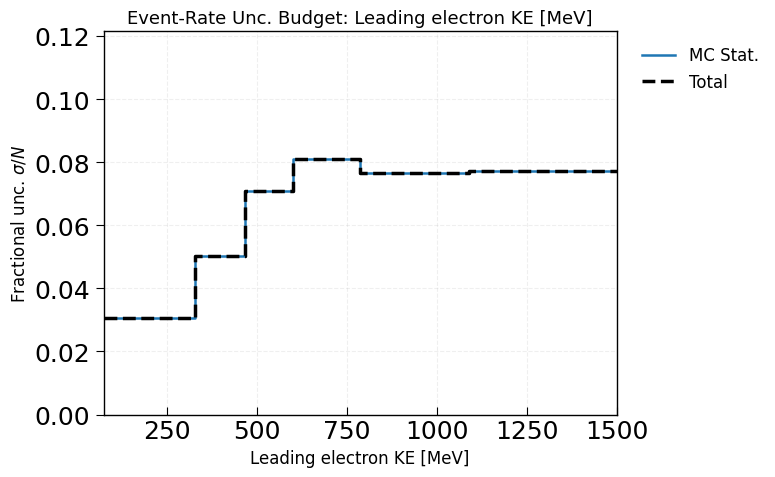

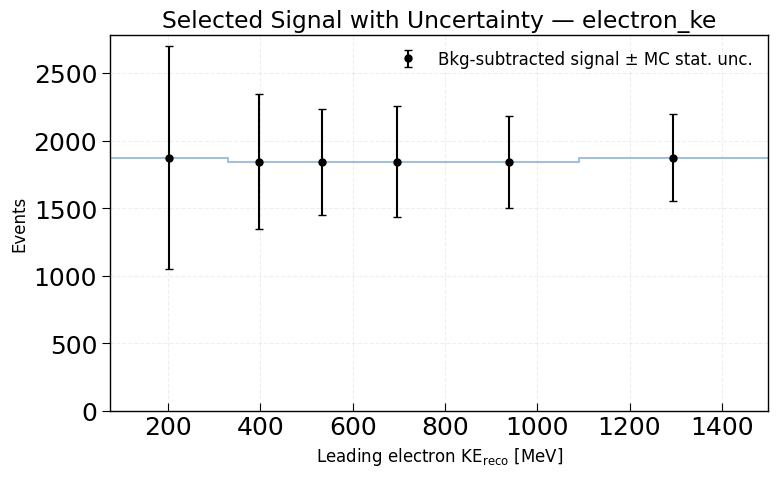

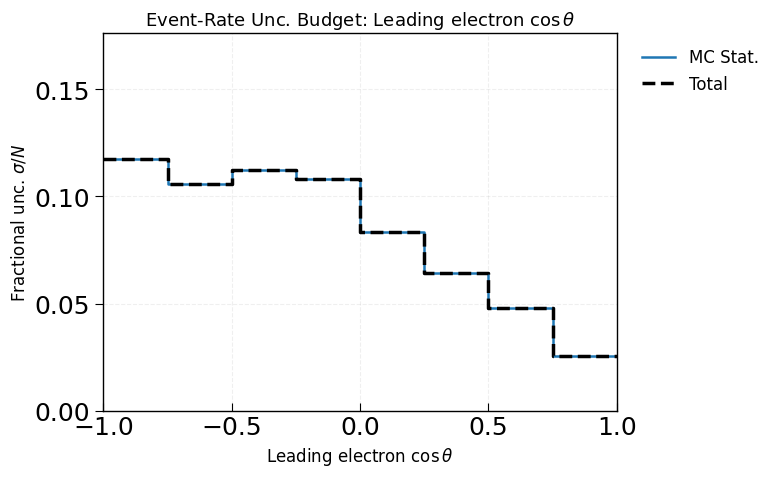

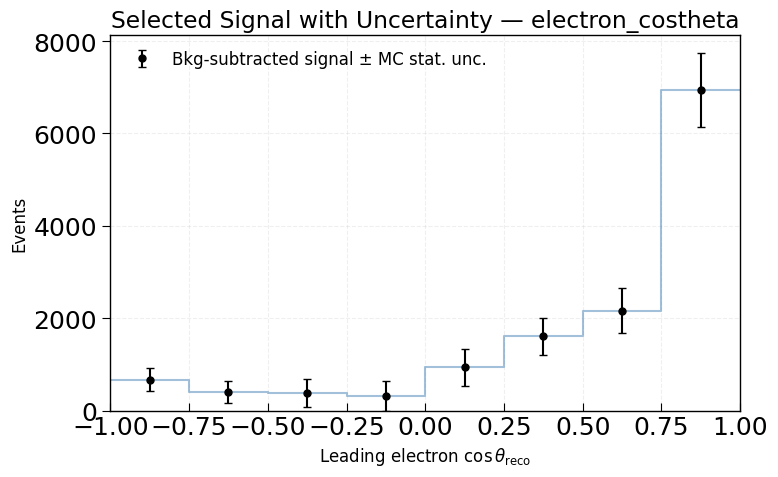

In [21]:
# CELL 20 — Uncertainty budget + signal with error bars (all variables)

from nue_xsec_helpers import plot_uncertainty_budget

for vc in VAR_CONFIGS:
    bins       = vc["bins"]
    h          = hists[vc["name"]]
    ret_mcstat = ret_mcstat_dict[vc["name"]]
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    class _VCfg:
        bins          = vc["bins"]
        var_labels    = [vc["label"], vc["label_reco"], vc["label_true"]]
        var_plot_name = vc["label"]
    _vcfg = _VCfg()

    cv_total      = h["nevts_total_reco"]
    cov_dict_reco = {
        "MC Stat.": ret_mcstat["Covariance"],
        # "Flux"   : ret_flux_dict[vc["name"]]["Covariance"],
        # "GENIE"  : ret_genie_dict[vc["name"]]["Covariance"],
    }

    fig, ax = plot_uncertainty_budget(
        _vcfg, cv_total, cov_dict_reco,
        title=f"Event-Rate Unc. Budget",
    )
    savefig(f"{vc['name']}_unc_budget.png")
    plt.show()

    total_cov = sum(cov_dict_reco.values())
    total_err = np.sqrt(np.diag(total_cov))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.step(bins, np.append(h["nevts_sig_reco"], h["nevts_sig_reco"][-1]),
            where="post", color="steelblue", lw=1.5, alpha=0.5)
    ax.errorbar(bin_centers, h["nevts_sig_reco"], yerr=total_err,
                fmt="ko", capsize=3, elinewidth=1.5, ms=5,
                label="Bkg-subtracted signal ± MC stat. unc.")
    ax.set_xlim(bins[0], bins[-1]); ax.set_ylim(bottom=0)
    ax.set_xlabel(vc["label_reco"], fontsize=12)
    ax.set_ylabel("Events", fontsize=12)
    ax.set_title(f"Selected Signal with Uncertainty — {vc['name']}")
    ax.legend(frameon=False, fontsize=12); ax.grid(alpha=0.2, ls="--")
    plt.tight_layout()
    savefig(f"{vc['name']}_signal_with_unc.png")
    plt.show()

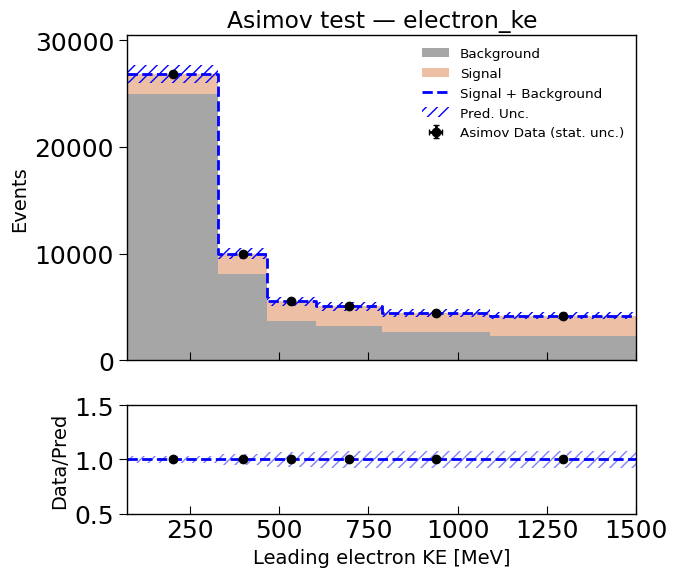

<Figure size 800x600 with 0 Axes>

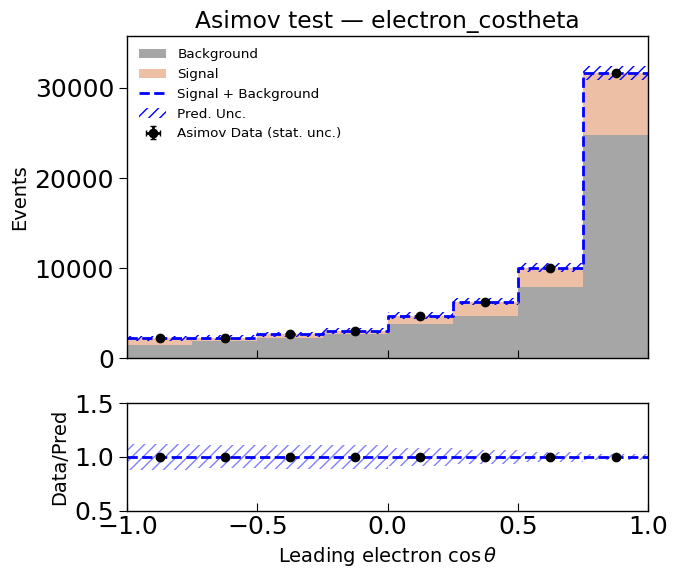

<Figure size 800x600 with 0 Axes>

In [22]:
# CELL 21 — Asimov data vs. prediction overlay (all variables)

for vc in VAR_CONFIGS:
    h          = hists[vc["name"]]
    ret_mcstat = ret_mcstat_dict[vc["name"]]

    class _VCfg:
        bins          = vc["bins"]
        var_labels    = [vc["label"], vc["label_reco"], vc["label_true"]]
        var_plot_name = vc["label"]
    _vcfg = _VCfg()

    plot_overlay_with_cov(
        data           = h["nevts_total_reco"],
        cov_data       = np.diag(h["nevts_total_reco"]),
        signal         = h["nevts_sig_reco"],
        cov_signal     = ret_mcstat["Covariance"],
        background     = h["nevts_bkg_reco"],
        cov_background = np.diag(h["nevts_bkg_reco"]),
        varcfg         = _vcfg,
        title          = f"Asimov test — {vc['name']}",
        data_label     = "Asimov Data (stat. unc.)",
        y_label_top    = "Events",
        ratio_y_min    = 0.5,
        ratio_y_max    = 1.5,
    )
    savefig(f"{vc['name']}_overlay_asimov.png")
    plt.show()

Running closure test: electron_ke …


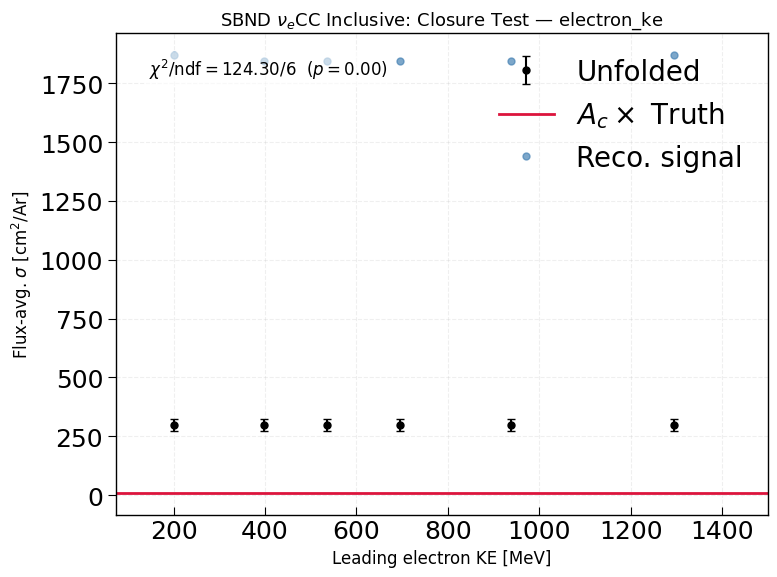

Running closure test: electron_costheta …


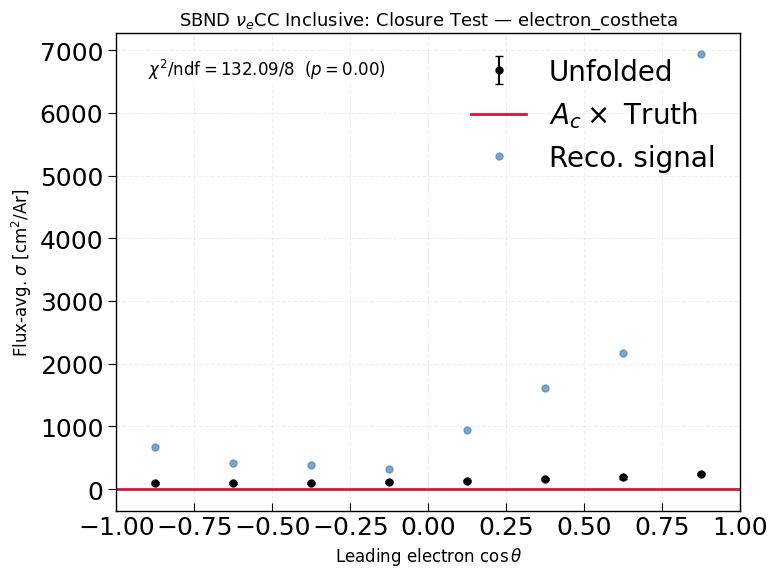

In [23]:
# CELL 22 — Wiener-SVD closure test (all variables)

from nue_xsec_helpers import plot_unfolded_result

unfold_closure_dict = {}

for vc in VAR_CONFIGS:
    bins       = vc["bins"]
    h          = hists[vc["name"]]
    ret_mcstat = ret_mcstat_dict[vc["name"]]
    Response   = Response_dict[vc["name"]]

    Model    = h["nevts_sig_truth"]   * XSEC_UNIT_EVENT
    Measured = h["nevts_sig_reco"]    * XSEC_UNIT_EVENT
    Cov_tot  = ret_mcstat["Covariance"]

    class _VCfg:
        bins          = vc["bins"]
        var_labels    = [vc["label"], vc["label_reco"], vc["label_true"]]
        var_plot_name = vc["label"]
    _vcfg = _VCfg()

    print(f"Running closure test: {vc['name']} …")
    unfold_closure = WienerSVD(Response, Model, Measured, Cov_tot,
                               C_type=2, Norm_type=0)
    unfold_closure_dict[vc["name"]] = dict(
        unfold=unfold_closure, Model=Model, Measured=Measured,
        Cov_tot=Cov_tot, vcfg=_vcfg,
    )

    fig, ax = plot_unfolded_result(
        _vcfg, unfold_closure,
        model       = Model,
        reco_signal = Measured,
        title       = f"{TITLE_PREFIX}: Closure Test — {vc['name']}",
    )
    savefig(f"{vc['name']}_unfolded_closure.png")
    plt.show()

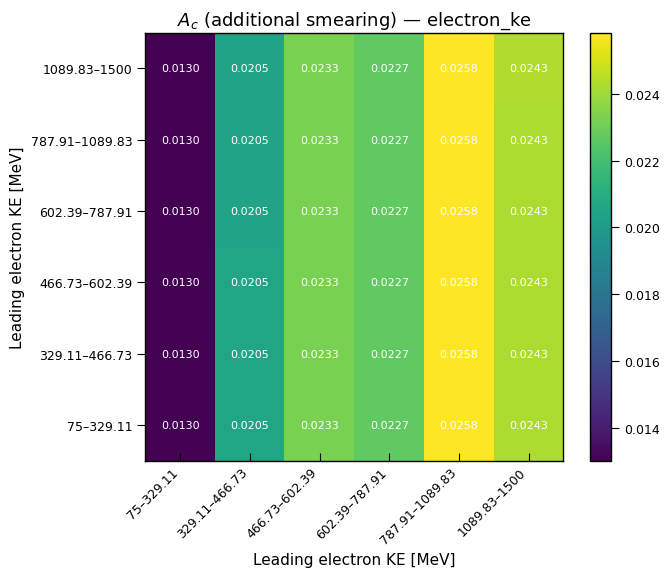

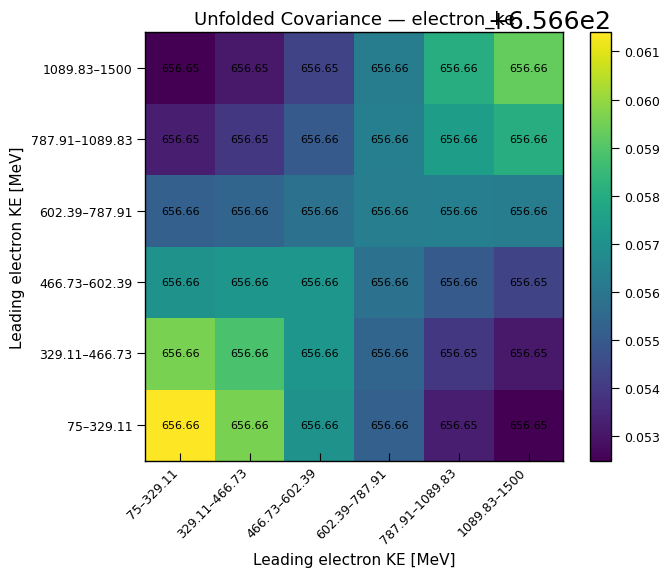

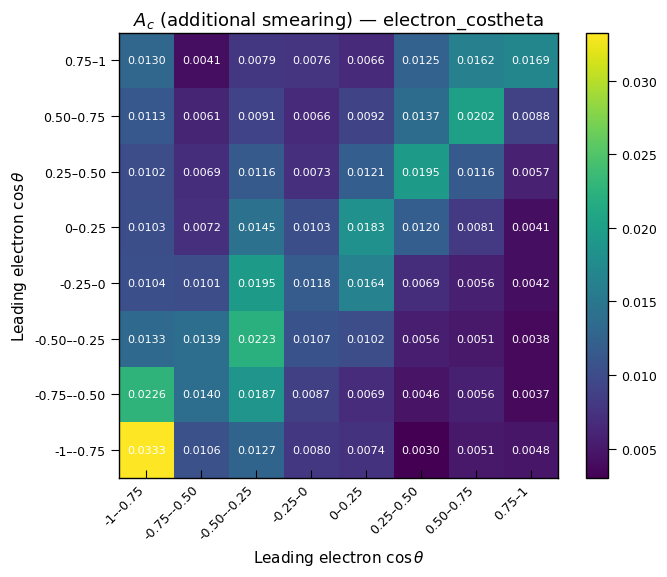

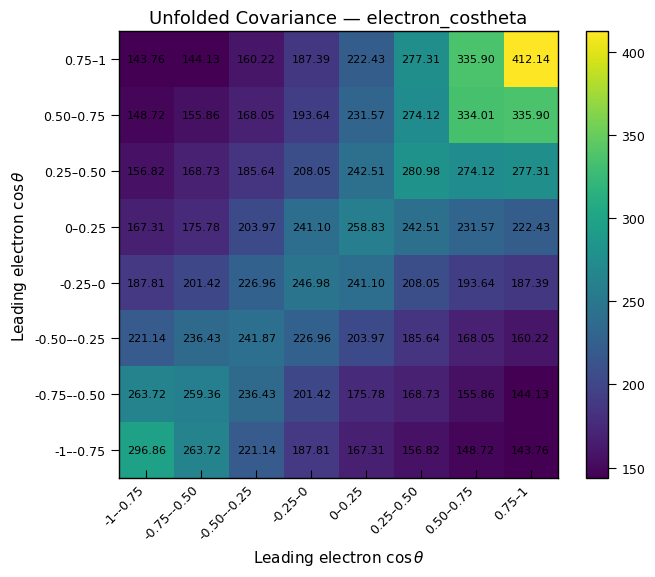

In [24]:
# CELL 23 — Ac matrix and unfolded covariance heatmaps (all variables)

for vc in VAR_CONFIGS:
    entry          = unfold_closure_dict[vc["name"]]
    unfold_closure = entry["unfold"]
    _vcfg          = entry["vcfg"]

    for matrix, title, fmt, lbl in [
        (unfold_closure["AddSmear"],  r"$A_c$ (additional smearing)", ".3f", "Ac"),
        (unfold_closure["UnfoldCov"], "Unfolded Covariance",          ".2e", "unfoldcov"),
    ]:
        fig, ax = plot_heatmap(
            matrix, f"{title} — {vc['name']}", _vcfg,
            axis_labels=[vc["label"], vc["label"]],
            fmt=fmt,
        )
        savefig(f"{vc['name']}_{lbl}.png")
        plt.show()

In [25]:
# CELL 24 — Fake data test driver (updated to take vc explicitly)

def run_fake_data_test(scale_dict, label, vc,
                       sel_df, sig_mask_sel, bkg_mask_sel,
                       mcstat_df, pot_scale,
                       Response, Model, Cov,
                       presel_sig_df, XSEC_UNIT_EVENT,
                       C_type=2, Norm_type=0):

    bins = vc["bins"]
    rc   = vc["reco_col"]
    tc   = vc["true_col"]
    lo, hi = bins[0], bins[-1]
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Strict range
    sig_range = sig_mask_sel & sel_df[rc].notna() & (sel_df[rc] >= lo) & (sel_df[rc] < hi)
    bkg_range = bkg_mask_sel & sel_df[rc].notna() & (sel_df[rc] >= lo) & (sel_df[rc] < hi)

    wgt_fake = np.full(len(sel_df), pot_scale, dtype=float)
    for cat, scale in scale_dict.items():
        wgt_fake[sel_df["truth_cat"].values == cat] *= scale

    fake_sig_hist, _ = np.histogram(
        sel_df.loc[sig_range, rc].values, bins=bins,
        weights=wgt_fake[sig_range.values],
    )
    fake_bkg_hist, _ = np.histogram(
        sel_df.loc[bkg_range, rc].values, bins=bins,
        weights=wgt_fake[bkg_range.values],
    )
    cv_bkg, _ = np.histogram(sel_df.loc[bkg_range, rc].values, bins=bins,
                              weights=np.full(bkg_range.sum(), pot_scale))
    Measured_fake = (fake_sig_hist - (fake_bkg_hist - cv_bkg)) * XSEC_UNIT_EVENT

    unfold_fake = WienerSVD(Response, Model, Measured_fake, Cov, C_type, Norm_type)

    alt_truth = hists[vc["name"]]["nevts_sig_truth"].copy().astype(float)
    if 0 in scale_dict:
        pre_true = _in_range(presel_sig_df[tc].values, lo, hi)
        cv_b, _  = np.histogram(pre_true, bins=bins)
        alt_b, _ = np.histogram(pre_true, bins=bins,
                                 weights=np.full(len(pre_true), scale_dict[0]))
        alt_truth += (alt_b - cv_b)

    U, Uc  = unfold_fake["unfold"], unfold_fake["UnfoldCov"]
    Uerr   = np.sqrt(np.diag(Uc))
    Ac     = unfold_fake["AddSmear"]
    model_smear = Ac @ Model
    alt_smear   = Ac @ (alt_truth * XSEC_UNIT_EVENT)

    def _chi2(a, b, C):
        return float((a - b) @ np.linalg.inv(C) @ (a - b))

    c2_nom = _chi2(U, model_smear, Uc)
    c2_alt = _chi2(U, alt_smear,   Uc)
    ndf    = len(U)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.step(bins, np.append(U, U[-1]), where="post",
            color="black", lw=2, label="Unfolded")
    ax.bar(bin_centers, 2*Uerr, width=np.diff(bins),
           bottom=U - Uerr, color="gray", alpha=0.4, lw=0, label="Unfolded unc.")
    ax.plot(bin_centers, Measured_fake, "o", color="steelblue", ms=5,
            label="Reco. signal (fake data)")
    ax.plot(bin_centers, model_smear, "s", color="crimson", ms=5,
            label=r"$A_c\times$ Nominal ($\chi^2/{\rm ndf}=%.2f/%d$)" % (c2_nom, ndf))
    ax.plot(bin_centers, alt_smear, "D", color="darkorange", ms=5,
            label=r"$A_c\times$ " + label
                  + r" ($\chi^2/{\rm ndf}=%.2f/%d$)" % (c2_alt, ndf))
    ax.set_xlim(bins[0], bins[-1])
    ax.set_xlabel(vc["label"], fontsize=12)
    ax.set_ylabel("Events", fontsize=12)
    ax.set_title(f"{TITLE_PREFIX}: Fake Data — {label} [{vc['name']}]", fontsize=12)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(alpha=0.2, ls="--")
    plt.tight_layout()
    return fig, ax, unfold_fake

presel_sig_df = sel_qual[presel_sig_mask]

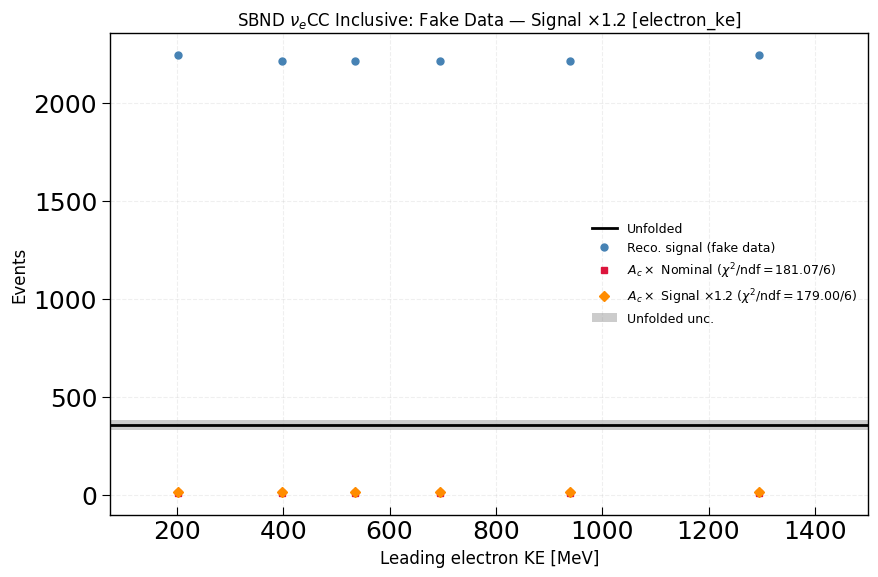

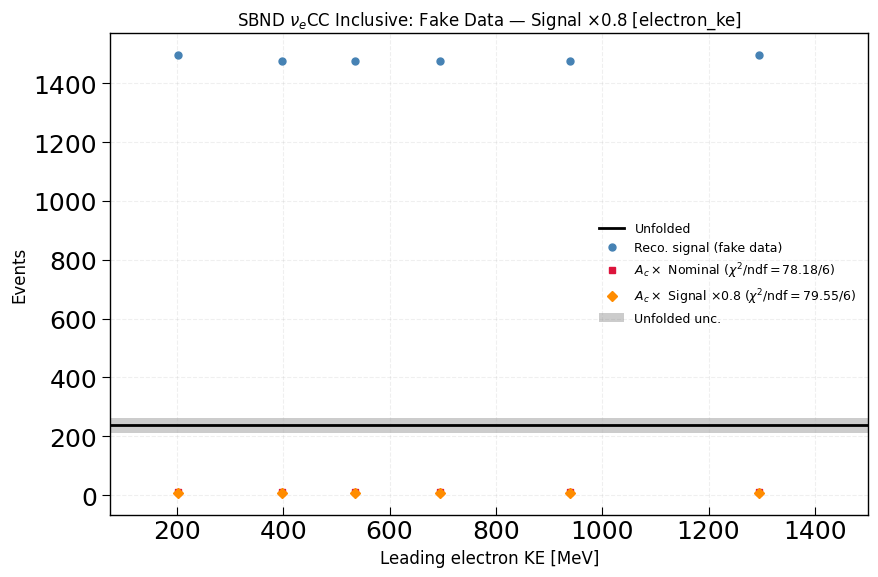

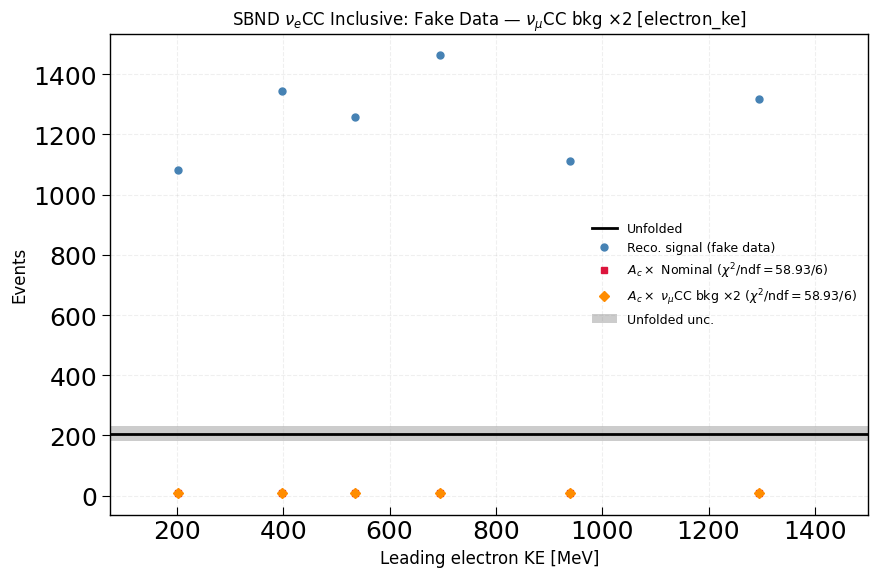

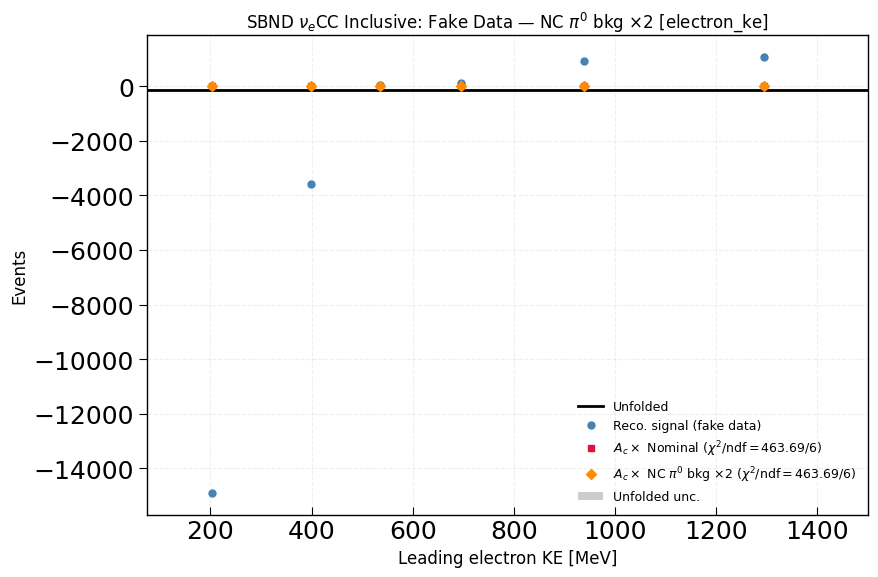

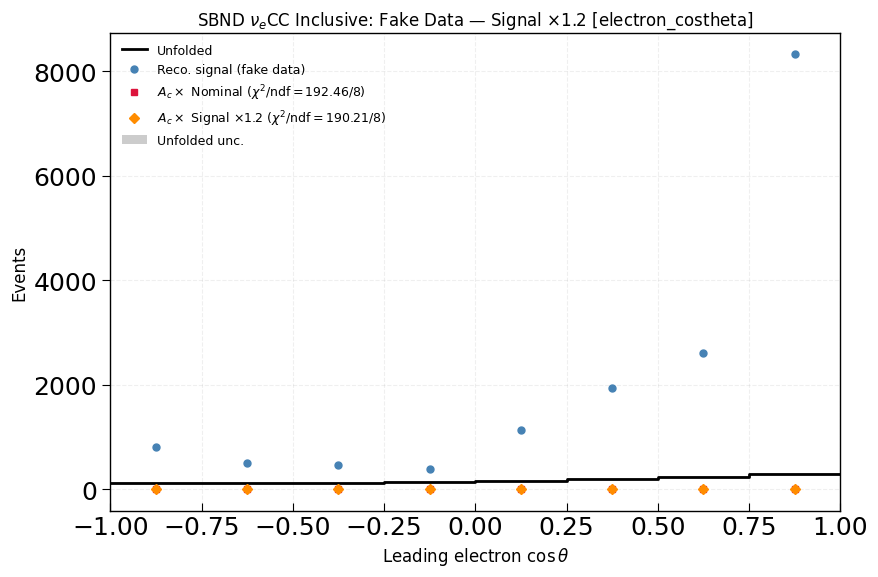

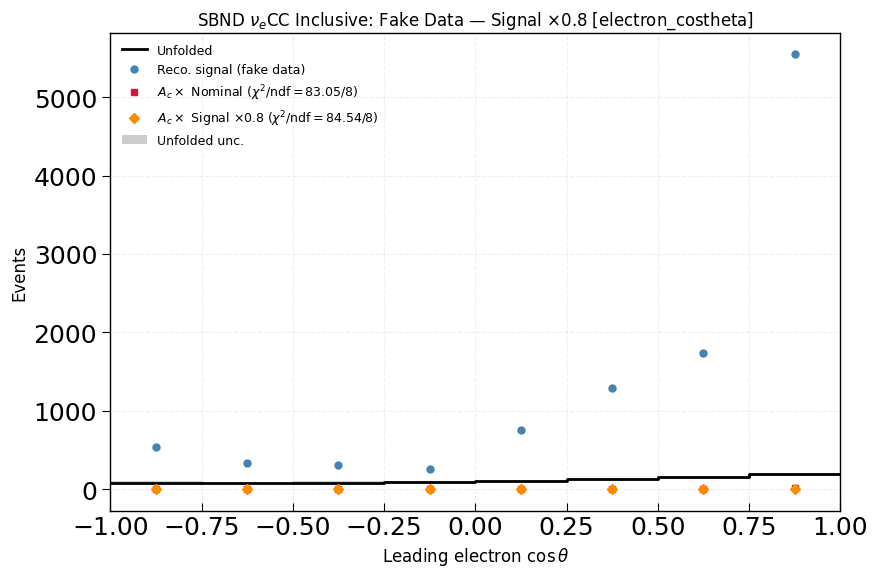

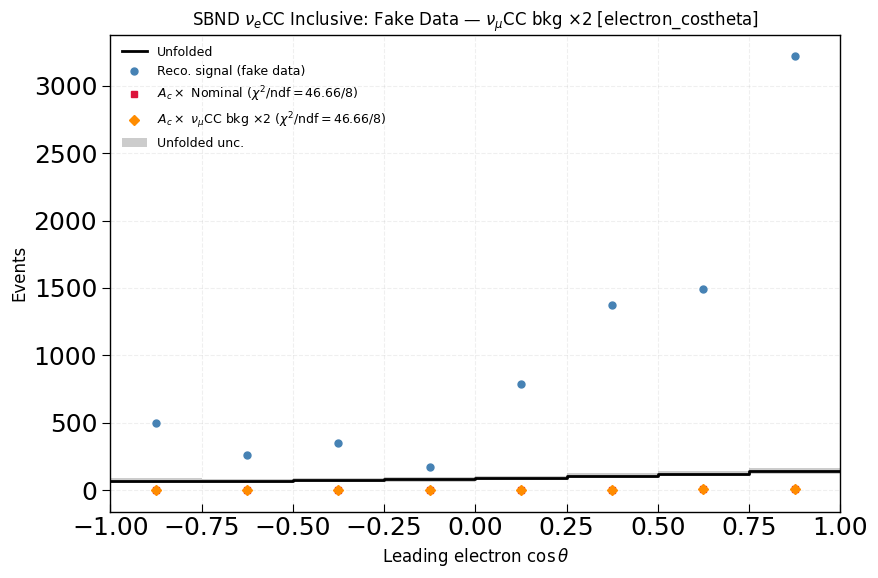

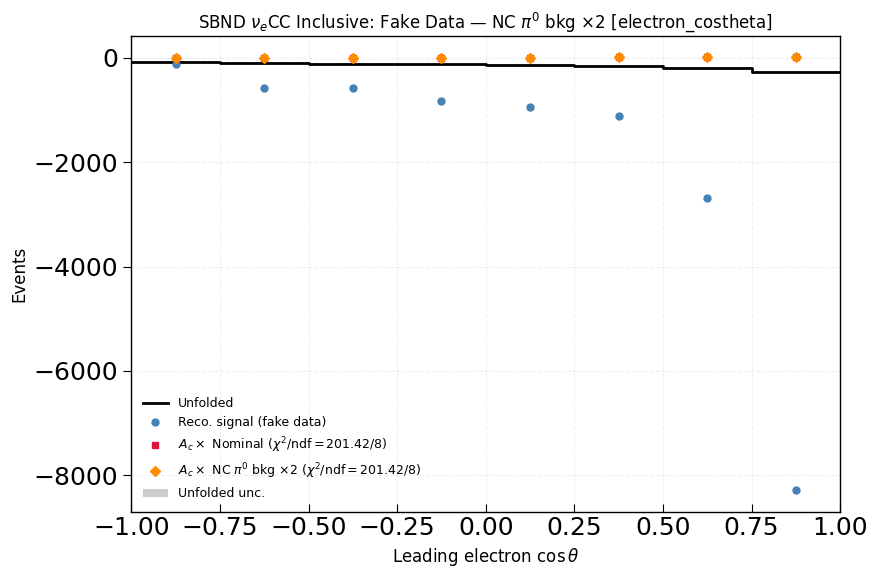

In [26]:
# CELL 25 — Fake data tests (all variables × all scenarios)

FAKE_DATA_TESTS = [
    ({0: 1.2},        "Signal ×1.2",              "fake_sig_x1p2"),
    ({0: 0.8},        "Signal ×0.8",              "fake_sig_x0p8"),
    ({2: 2.0, 4: 2.0},r"$\nu_\mu$CC bkg ×2",     "fake_numubkg_x2"),
    ({3: 2.0},        r"NC $\pi^0$ bkg ×2",       "fake_ncpi0_x2"),
]

unfold_fake_dict = {}   # keyed by (var_name, test_tag)

for vc in VAR_CONFIGS:
    entry    = unfold_closure_dict[vc["name"]]
    Model    = entry["Model"]
    Cov_tot  = entry["Cov_tot"]
    Response = Response_dict[vc["name"]]

    unfold_fake_dict[vc["name"]] = {}

    for scale_dict, label, tag in FAKE_DATA_TESTS:
        fig, ax, uf = run_fake_data_test(
            scale_dict, label, vc,
            sel_df, sig_mask_sel, bkg_mask_sel,
            mcstat_df, pot_scale,
            Response, Model, Cov_tot,
            presel_sig_df, XSEC_UNIT_EVENT,
        )
        unfold_fake_dict[vc["name"]][tag] = uf
        savefig(f"{vc['name']}_{tag}.png")
        plt.show()

In [27]:
# CELL 26 — χ²/ndf summary table (all variables)

print(f"\n{'Variable':<20} {'Test':<30}  chi2    ndf   p-val")
print("-" * 72)

for vc in VAR_CONFIGS:
    entry          = unfold_closure_dict[vc["name"]]
    Model          = entry["Model"]
    unfold_closure = entry["unfold"]

    test_cases = [("Closure (Asimov)", unfold_closure)] + [
        (label, unfold_fake_dict[vc["name"]][tag])
        for _, label, tag in FAKE_DATA_TESTS
    ]

    for label, uf in test_cases:
        U  = uf["unfold"]
        Uc = uf["UnfoldCov"]
        Ms = uf["AddSmear"] @ Model
        c2 = float((U - Ms) @ np.linalg.inv(Uc) @ (U - Ms))
        ndf = len(U)
        pv  = 1 - scipy_chi2.cdf(c2, ndf)
        print(f"  {vc['name']:<18} {label:<30}  {c2:6.2f}   {ndf}   {pv:.3f}")
    print()


Variable             Test                            chi2    ndf   p-val
------------------------------------------------------------------------
  electron_ke        Closure (Asimov)                124.30   6   0.000
  electron_ke        Signal ×1.2                     181.07   6   0.000
  electron_ke        Signal ×0.8                      78.18   6   0.000
  electron_ke        $\nu_\mu$CC bkg ×2               58.93   6   0.000
  electron_ke        NC $\pi^0$ bkg ×2               463.69   6   0.000

  electron_costheta  Closure (Asimov)                132.09   8   0.000
  electron_costheta  Signal ×1.2                     192.46   8   0.000
  electron_costheta  Signal ×0.8                      83.05   8   0.000
  electron_costheta  $\nu_\mu$CC bkg ×2               46.66   8   0.000
  electron_costheta  NC $\pi^0$ bkg ×2               201.42   8   0.000



In [28]:
# CELL 27 — npz archiving placeholder (all variables, uncomment when weights ready)

# from nue_xsec_helpers import save_cov_npz
# for vc in VAR_CONFIGS:
#     h          = hists[vc["name"]]
#     ret_mcstat = ret_mcstat_dict[vc["name"]]
#     Response   = Response_dict[vc["name"]]
#     save_cov_npz(
#         f"{vc['name']}_mcstat_cov_matrices.npz",
#         response            = Response,
#         true_signal         = h["nevts_sig_truth"]  * XSEC_UNIT,
#         measured_signal     = h["nevts_sig_reco"]   * XSEC_UNIT,
#         measured_background = h["nevts_bkg_reco"]   * XSEC_UNIT,
#         cov_ms_ms           = {"cov": ret_mcstat["Covariance"]},
#         cov_bs_bs           = {"cov": np.zeros_like(ret_mcstat["Covariance"])},
#     )

print("npz archiving ready — uncomment when syst. weights are available.")

npz archiving ready — uncomment when syst. weights are available.
